# Module 15b — Radial Arcs & Caustic Topology: Realistic PyAutoLens Demos

## Learning to Autolens / Modules / 15b

**This notebook is the second half of the split-up Module 15.** It picks up
where **`Modules/15a_Radial_Arcs_Analytic_Foundation/15a_radial_arcs_analytic.ipynb`**
leaves off: 15a built the analytic-axisymmetric foundation (critical curves,
caustics, $\beta_r(\gamma')$, the 2D ray-traced source-position + γ′ sweeps),
ending with the *single-radius-slice* form of the γ′–M_BH degeneracy. 15b
builds the realistic spiral-lens demonstrations that show how that
single-radius degeneracy is transcended by joint tangential + radial
constraints from extended sheared sources.

**Why this module exists, restated for 15b.** AGEL spiral-lens UMBH
detections (Shajib et al. "first Einstein spiral", Ferrami et al. DESJ0206
ApJL) work because the lens images include both a tangential ring (constrains
total mass inside $\theta_E$) AND radial arc features (constrain inner mass
*shape*) from the *same* extended source. 15b's seven sections build that
demonstration in PyAutoLens, the same framework as the rest of the
curriculum (Mod 03+, all `Examples/`).

**Theory-first transition: why PyAutoLens here.** 15a was pure numpy because
the radial-arc physics is *axisymmetric* in the analytic limit — a heavy
framework would obscure the geometry. 15b's setup is elliptical, multi-class
(PL / BPL / NSC / SMBH), and uses real-target-flavoured source structures.
PyAutoLens's mass-profile library, critical-curve / caustic utilities, and
log-space rendering are exactly the right tools for this regime. The
companion `Examples/radial_arc_smbh/` then runs the *fitting* (Nautilus
posterior) of the same physics; 15b stays on the *forward-model* side.

**Roadmap.**

1. **Same total mass, different mass shape** — point-source PL+SMBH composite
   (the topology-change demo; uses only numpy for the simulation but already
   introduces the composite-mass math).
2. **Spiral-source extension** — structured extended source with three
   matched-tangential composite lens models, quantifying inner vs outer
   RMS difference.
3. **4-class PyAutoLens comparison** — PL γ-vary | BPL | PL+NSC | PL+SMBH at
   matched outer Einstein ring.
4. **Student `base_class 1-4` rotations** + the ±SMBH critical comparison
   (uses the exact SED_inferred_color_images parameters via the
   `_spiral_lens_helpers` module in this directory).
4c. **NSC vs SMBH** at matched total mass, varying NSC compactness.
5. **Fake DESJ0206** — EPL γ=1.7 + 2 source blobs inside the caustic
   (multi-arc spiral morphology).
6. **Lensing-alone (γ′, M_BH) constraints — the spiral-lens advantage**
   (revised framing: the DESJ0206 BPL $r_{\rm break}\le 10$ pc result).
7. **Hand-off** to `Examples/radial_arc_smbh/`, Module 13, AGEL paper references.

**Prerequisites.** Module 15a (the analytic foundation above). Modules 01,
03, 11. PyAutoLens 2026.4.13+ installed (`autolens312` conda env on Cannon,
`autolens` env locally). The helper module `_spiral_lens_helpers.py` in this
directory holds the composite-mass builders (`build_pl_only_tracer`,
`build_bpl_tracer`, `build_pl_nsc_tracer`, `build_sie_smbh_tracer`),
`q_phi_to_ell_comps`, `verify_alpha_matches_baseline`, and
`critical_curves_caustics` / `plot_critical_curves`.

**Time.** ~30 min reading. ~1–2 min laptop execute (PyAutoLens rendering of
~12 forward-model passes, no fitting). No Cannon dependency.

**References.** Shajib et al. *"An ultramassive black hole 7.1 Gyr ago in
the first 'Einstein spiral' gravitational lens"*; Ferrami et al. *"Detection
of a quiescent billion solar mass black hole at z≈0.7 with gravitational
lensing"* (DESJ0206 ApJL); Nightingale et al. 2023 (A1201 BCG SMBH);
Auger+10, Sonnenfeld+13 (the classical SLACS / SL2S kinematic-break
methodology that 15b complements).


In [1]:
# 15b imports — numpy + PyAutoLens, plus path setup so the local helpers module loads.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

# Re-declare the analytic axisymmetric machinery from 15a §1 — needed by §1, §2,
# §5 (the "fake DESJ0206" radial-caustic estimate). Kept inline so 15b is
# self-contained without importing from 15a's directory.
def kappa_pl(r, theta_E=1.0, gamma=2.0):
    return (3 - gamma) / 2 * (theta_E / r) ** (gamma - 1)

def alpha_pl(r, theta_E=1.0, gamma=2.0):
    return theta_E * (theta_E / r) ** (gamma - 2)

def shear_pl(r, theta_E=1.0, gamma=2.0):
    return alpha_pl(r, theta_E, gamma) / r - kappa_pl(r, theta_E, gamma)

def lambda_t(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) - shear_pl(r, theta_E, gamma)

def lambda_r(r, theta_E=1.0, gamma=2.0):
    return 1 - kappa_pl(r, theta_E, gamma) + shear_pl(r, theta_E, gamma)

def find_critical_radii(theta_E=1.0, gamma=2.0):
    try:
        r_t = brentq(lambda r: lambda_t(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_t = None
    try:
        r_r = brentq(lambda r: lambda_r(r, theta_E, gamma), 1e-4, 5.0)
    except ValueError:
        r_r = None
    return r_t, r_r

# theta_circ_2 reused across multiple cells for caustic / critical-curve plotting
theta_circ_2 = np.linspace(0, 2 * np.pi, 200)


## 1. Same total mass, different mass *shape* — when the radial image breaks the degeneracy

15a closed with the *single-radius-slice* degeneracy: a global PL fit to a
(PL + SMBH) truth returns an apparent γ′_eff > 2 from the cumulative
$\bar\kappa(<\theta_E)$ alone. This section makes the **image-plane reason
why** the degeneracy is broken **when a radial image is produced** concrete by
simulation.

**The experiment.** Build two mass models with identical total mass inside
the tangential Einstein radius $\theta_E$:

- **Model A — pure PL** with $\gamma'=1.85$, $\theta_E = 1^{\prime\prime}$. All mass smoothly distributed.
- **Model B — PL + central SMBH** with the same $\theta_E$. A fraction $f_{\rm BH} = \theta_{\rm BH}^2/\theta_E^2$ of the total enclosed mass is in the central point; the PL component is shrunk to $\theta'_E = \theta_E (1 - f_{\rm BH})^{1/(\gamma'-1)}$ so that $\alpha_{\rm composite}(\theta_E) = \theta_E$ is preserved. **The tangential Einstein ring lands at exactly the same radius for both models.**

**The question.** When does swapping Model A → Model B change the observed image?

**The answer this section demonstrates:**

- **Source OUTSIDE the radial caustic** (tangential arcs only): Models A and B produce essentially *indistinguishable* images. The 1% of mass concentrated in the BH is invisible because the tangential arc only constrains $\bar\kappa(<\theta_E)$, which is the same in both models by construction.
- **Source INSIDE the radial caustic** (radial image triggered): the two models produce *dramatically different* images. Model A has a clean 3-image configuration (tangential pair + radial arc). Model B's radial caustic has been *destroyed* by the SMBH's positive shear at small radius, so only the tangential pair remains.

**This is the geometric origin of the UMBH constraint.** The radial image
acts as a high-resolution probe of inner mass *shape* (not just enclosed
mass). The shape of the gravitational potential matters *even if the total
mass contribution from the central concentration is quite minimal* —
provided the geometry produces a radial image to be sensitive to it.


> **What "same total mass" means here, precisely.** The shrinkage formula
> 
> $$\theta_{E,\rm PL}' = \theta_{E,\rm target}\,(1 - f_{\rm BH})^{1/(\gamma-1)}$$
> 
> preserves the *total enclosed mass at* $\theta_E$ — equivalently, the tangential Einstein-ring position is identical between Model A and Model B because $M(<\theta_E)$ is the same. **Inside** $\theta_E$, however, Model B has up to $f_{\rm BH}\cdot\theta_E$ extra mass at the centre (the point mass) that the depleted PL component only partially offsets at smaller radii. Full $M(<r)$ equality between A and B is *mathematically impossible* because a point mass contributes $M_{\rm BH}$ to $M(<r)$ at every $r>0$ — there is no way to subtract a delta function uniformly from a smooth profile without making the latter negative somewhere.
>
> The standard astrophysical convention — what we use here, what Nightingale+2023 use, and what the AGEL papers use — is to **preserve $M(<\theta_E)$ and accept the inner-region $M(<r)$ difference as the variable that the radial arc constrains.** §3.7 and §3.8 below use the same construction. §3.9 (PyAutoLens) applies the same logic with the linear formula $\theta_{E,\rm SIE}' = \theta_E - \theta_{E,\rm BH}^2/\theta_E$, which is exact for SIS+POINT_MASS and ≤1% accurate for SIE.


Model A: pure PL, γ=1.85, θ_E=1.0
Model B: PL+SMBH, γ=1.85, θ_E=1.0; PL θ_E' = 0.9882, θ_BH = 0.1000" (f_BH = 1.0%)

Total mass inside θ_E (∝ α(θ_E)·θ_E for axisymmetric):
  Model A: α(θ_E)·θ_E = 1.000000
  Model B: α(θ_E)·θ_E = 1.000000
   → equal by construction. The two models have IDENTICAL total mass inside θ_E.



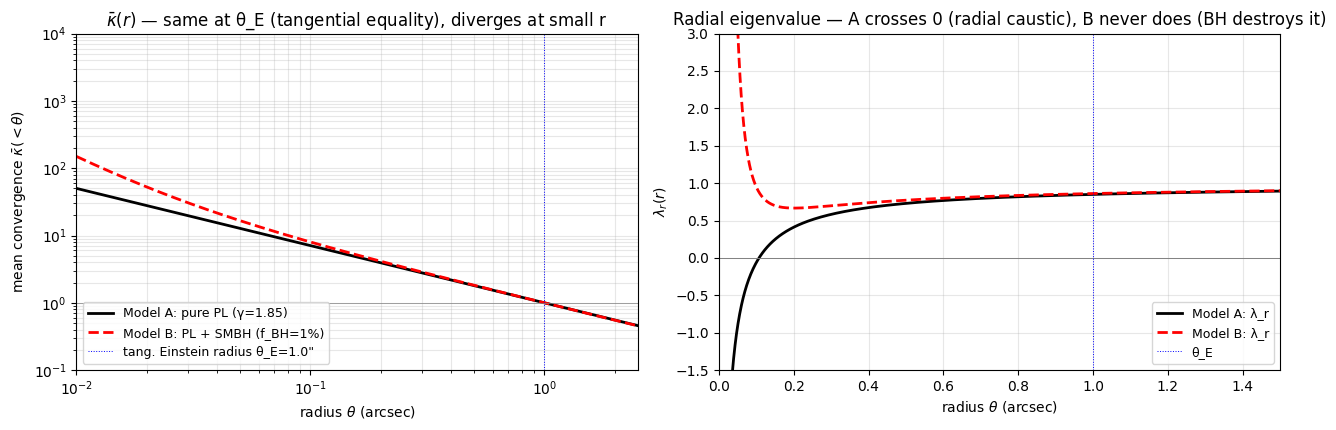

Number of radial critical curves:
  Model A: 1 (the usual PL radial caustic at r_r≈0.11")
  Model B: 0 — the BH's positive shear at small r has pushed λ_r > 0 everywhere.
           No radial caustic → no radial image regardless of source position.


In [2]:
# Composite-mass utilities: PL + point-mass SMBH with the PL component shrunk
# so the total tangential Einstein radius is preserved.

def adjust_theta_E_pl(theta_E_target, f_BH, gamma):
    """PL Einstein radius θ_E' such that composite α(θ_E_target) = θ_E_target.
    Derivation: α_composite(θ_E) = θ_E' * (θ_E'/θ_E)^(γ-2) + θ_BH²/θ_E = θ_E.
    With θ_BH² = f_BH * θ_E, this gives θ_E'^(γ-1) = θ_E^(γ-1)(1 - f_BH),
    so θ_E' = θ_E * (1 - f_BH)^(1/(γ-1)).
    """
    if f_BH >= 1.0:
        raise ValueError('f_BH must be < 1 (cannot put all mass in BH)')
    return theta_E_target * (1 - f_BH) ** (1.0 / (gamma - 1))


def alpha_composite(r, theta_E_total=1.0, gamma=1.85, f_BH=0.0):
    """Deflection of PL+SMBH composite at radius r, with total tangential E.R.
    held at theta_E_total."""
    theta_E_pl = adjust_theta_E_pl(theta_E_total, f_BH, gamma)
    theta_BH_sq = f_BH * theta_E_total
    return alpha_pl(r, theta_E_pl, gamma) + theta_BH_sq / r


def kappa_bar_composite(r, theta_E_total=1.0, gamma=1.85, f_BH=0.0):
    """Mean convergence inside radius r: κ̄ = α/r."""
    return alpha_composite(r, theta_E_total, gamma, f_BH) / r


def lambda_r_composite(r, theta_E_total=1.0, gamma=1.85, f_BH=0.0):
    """Radial eigenvalue λ_r = 1 - 2κ + κ̄, where κ is from the PL component only
    (BH is a delta-function at origin; contributes only to κ̄ via 1/r² shear)."""
    theta_E_pl = adjust_theta_E_pl(theta_E_total, f_BH, gamma)
    kappa_pl_val = (3 - gamma) / 2 * (theta_E_pl / r) ** (gamma - 1)
    return 1 - 2 * kappa_pl_val + alpha_composite(r, theta_E_total, gamma, f_BH) / r


# Compare two models at γ=1.85, θ_E=1, with f_BH = 0 vs 0.01 (1% of mass in BH).
GAMMA = 1.85
TE = 1.0
F_BH = 0.01            # 1% of total mass concentrated as a point
theta_BH = np.sqrt(F_BH * TE)
theta_E_pl_B = adjust_theta_E_pl(TE, F_BH, GAMMA)

print(f'Model A: pure PL, γ={GAMMA}, θ_E={TE}')
print(f'Model B: PL+SMBH, γ={GAMMA}, θ_E={TE}; PL θ_E\' = {theta_E_pl_B:.4f}, '
      f'θ_BH = {theta_BH:.4f}\" (f_BH = {F_BH*100:.1f}%)')
print()
print(f'Total mass inside θ_E (∝ α(θ_E)·θ_E for axisymmetric):')
print(f'  Model A: α(θ_E)·θ_E = {alpha_pl(TE, TE, GAMMA)*TE:.6f}')
print(f'  Model B: α(θ_E)·θ_E = {alpha_composite(TE, TE, GAMMA, F_BH)*TE:.6f}')
print(f'   → equal by construction. The two models have IDENTICAL total mass inside θ_E.\n')

# κ̄(r), α(r) profile comparison
rs = np.geomspace(0.01, 2.5, 400)
kbar_A = kappa_bar_composite(rs, TE, GAMMA, f_BH=0.0)
kbar_B = kappa_bar_composite(rs, TE, GAMMA, f_BH=F_BH)
lr_A = np.array([lambda_r_composite(r, TE, GAMMA, 0.0) for r in rs])
lr_B = np.array([lambda_r_composite(r, TE, GAMMA, F_BH) for r in rs])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.loglog(rs, kbar_A, 'k-', lw=2, label=f'Model A: pure PL (γ={GAMMA})')
ax.loglog(rs, kbar_B, 'r--', lw=2, label=f'Model B: PL + SMBH (f_BH={F_BH*100:.0f}%)')
ax.axvline(TE, color='blue', lw=0.7, ls=':', label=f'tang. Einstein radius θ_E={TE}\"')
ax.axhline(1.0, color='gray', lw=0.5)
ax.set_xlabel(r'radius $\theta$ (arcsec)')
ax.set_ylabel(r'mean convergence $\bar\kappa(<\theta)$')
ax.set_title(r'$\bar\kappa(r)$ — same at θ_E (tangential equality), diverges at small r')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=9, loc='lower left')
ax.set_xlim(0.01, 2.5); ax.set_ylim(0.1, 1e4)

ax = axes[1]
ax.plot(rs, lr_A, 'k-', lw=2, label=f'Model A: λ_r')
ax.plot(rs, lr_B, 'r--', lw=2, label=f'Model B: λ_r')
ax.axhline(0, color='gray', lw=0.7)
ax.axvline(TE, color='blue', lw=0.7, ls=':', label=f'θ_E')
ax.set_xlabel(r'radius $\theta$ (arcsec)')
ax.set_ylabel(r'$\lambda_r(r)$')
ax.set_title(r'Radial eigenvalue — A crosses 0 (radial caustic), B never does (BH destroys it)')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1.5); ax.set_ylim(-1.5, 3.0)

plt.tight_layout(); plt.show()

# Find roots of λ_r in each model
rs_fine = np.geomspace(1e-4, 2.0, 800)
lr_A_fine = np.array([lambda_r_composite(r, TE, GAMMA, 0.0) for r in rs_fine])
lr_B_fine = np.array([lambda_r_composite(r, TE, GAMMA, F_BH) for r in rs_fine])
n_zeros_A = np.sum(np.diff(np.sign(lr_A_fine)) != 0)
# Model A's pure-PL radial critical radius (for the print line below)
_, r_r = find_critical_radii(theta_E=TE, gamma=GAMMA)
n_zeros_B = np.sum(np.diff(np.sign(lr_B_fine)) != 0)
print(f'Number of radial critical curves:')
print(f'  Model A: {n_zeros_A} (the usual PL radial caustic at r_r≈{r_r:.2f}\")')
print(f'  Model B: {n_zeros_B} — the BH\'s positive shear at small r has pushed λ_r > 0 everywhere.')
print(f'           No radial caustic → no radial image regardless of source position.')


Model A radial caustic: |β_r| = 0.608", r_r = 0.107"

OUTSIDE caustic (β_x=0.730"):
  Image-plane RMS difference: 0.00478 (RMS of A: 0.03263, ratio: 14.65%)
  Max |A−B| pixel: 0.2137  (22.3% of brighter-image peak)

INSIDE caustic (β_x=0.213"):
  Image-plane RMS difference: 0.00369 (RMS of A: 0.09830, ratio: 3.75%)
  Max |A−B| pixel: 0.0560  (5.6% of brighter-image peak)


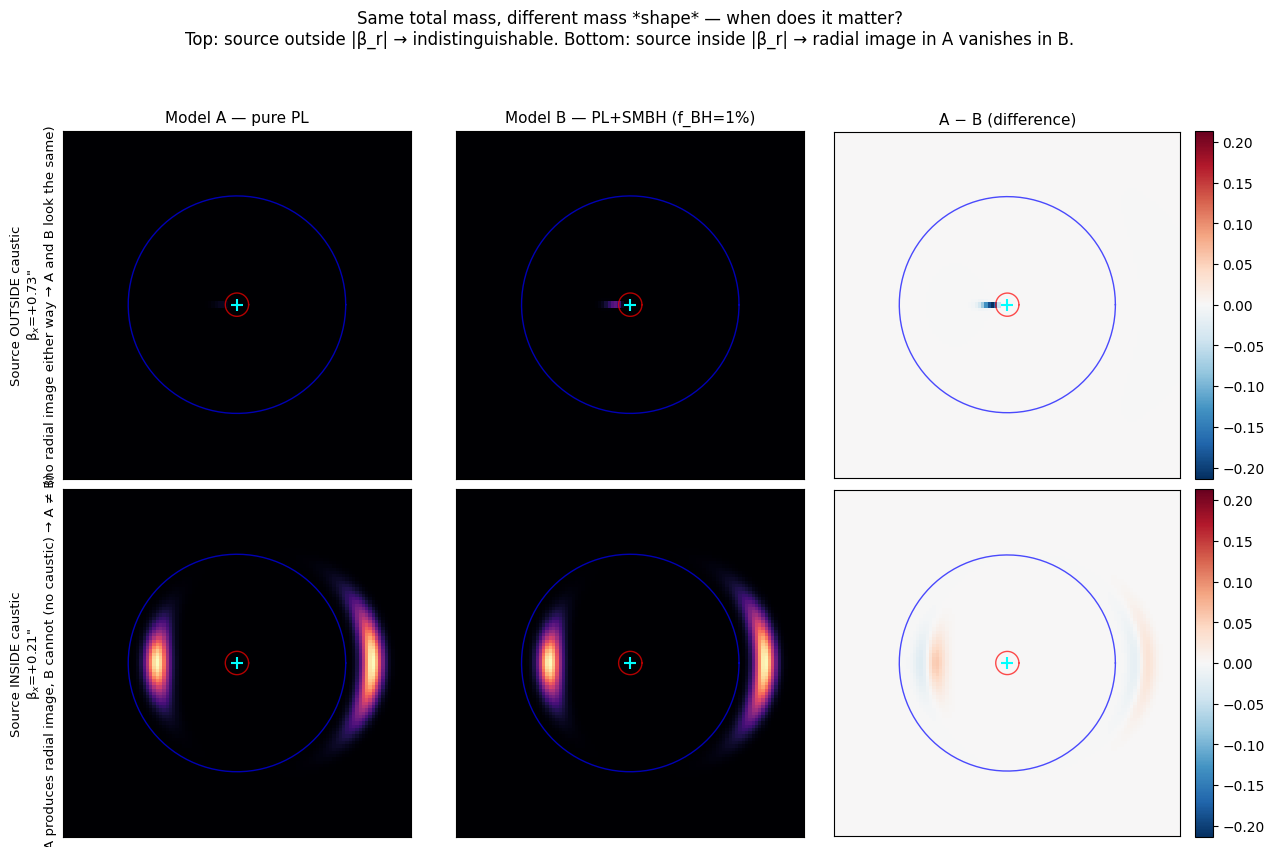

In [3]:
# Image-plane comparison: 2x3 grid (Model A | Model B | A-B difference).
# Top row: source OUTSIDE A's radial caustic (no radial image either way).
# Bottom row: source INSIDE A's radial caustic (radial image in A, gone in B).

def simulate_image_composite(theta_E_total=1.0, gamma=1.85, f_BH=0.0,
                              beta_x0=0.0, beta_y0=0.0, source_sigma=0.05,
                              source_amplitude=1.0, npix=120, fov=1.8):
    """Same ray-tracing as simulate_radial_arc_image but using the composite α."""
    edge = np.linspace(-fov, fov, npix)
    tx, ty = np.meshgrid(edge, edge)
    r = np.hypot(tx, ty)
    r_safe = np.where(r > 1e-6, r, 1e-6)
    alpha = alpha_composite(r_safe, theta_E_total, gamma, f_BH)
    bx = tx * (1.0 - alpha / r_safe)
    by = ty * (1.0 - alpha / r_safe)
    db = (bx - beta_x0)**2 + (by - beta_y0)**2
    return edge, source_amplitude * np.exp(-db / (2.0 * source_sigma**2))


# Pure-PL radial caustic radius for Model A
_, r_r_A = find_critical_radii(theta_E=TE, gamma=GAMMA)
beta_r_A = abs(r_r_A - alpha_pl(r_r_A, TE, GAMMA))
print(f'Model A radial caustic: |β_r| = {beta_r_A:.3f}\", r_r = {r_r_A:.3f}\"')

SOURCE_SIGMA = 0.06
src_positions = [
    ('OUTSIDE caustic',  1.20 * beta_r_A, 'no radial image either way → A and B look the same'),
    ('INSIDE caustic',   0.35 * beta_r_A, 'A produces radial image, B cannot (no caustic) → A ≠ B'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8.6))
theta_circ_2 = np.linspace(0, 2*np.pi, 200)

# Pre-compute global diff color range across both rows for fair visual comparison.
all_diffs = []
for _label, _bx, _ in src_positions:
    _, _imgA = simulate_image_composite(TE, GAMMA, 0.0, _bx, 0.0, SOURCE_SIGMA)
    _, _imgB = simulate_image_composite(TE, GAMMA, F_BH, _bx, 0.0, SOURCE_SIGMA)
    all_diffs.append(np.abs(_imgA - _imgB).max())
global_dvm = max(all_diffs)

for row, (label, beta_x, payoff) in enumerate(src_positions):
    edge, img_A = simulate_image_composite(TE, GAMMA, 0.0, beta_x, 0.0, SOURCE_SIGMA)
    _,   img_B = simulate_image_composite(TE, GAMMA, F_BH, beta_x, 0.0, SOURCE_SIGMA)
    diff = img_A - img_B
    vmax = max(img_A.max(), img_B.max())
    
    for col, (img, title_prefix, cmap) in enumerate([
        (img_A, 'Model A — pure PL',          'magma'),
        (img_B, f'Model B — PL+SMBH (f_BH={F_BH*100:.0f}%)', 'magma'),
        (diff,  'A − B (difference)',           'RdBu_r'),
    ]):
        ax = axes[row, col]
        if col == 2:
            dvm = global_dvm   # shared across both rows for fair comparison
            im = ax.imshow(img, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                           origin='lower', cmap=cmap, vmin=-dvm, vmax=dvm)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            ax.imshow(img, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
                      origin='lower', cmap=cmap, vmin=0, vmax=vmax)
        ax.plot(np.cos(theta_circ_2), np.sin(theta_circ_2), 'b-', lw=1.0, alpha=0.7)
        ax.plot(r_r_A * np.cos(theta_circ_2), r_r_A * np.sin(theta_circ_2),
                'r-', lw=1.0, alpha=0.7)  # only relevant for A; show on all for ref
        ax.plot(0, 0, '+', color='cyan', markersize=8, mew=1.5)
        ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(title_prefix, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'Source {label}\nβ$_x$={beta_x:+.2f}\"\n({payoff})',
                          fontsize=9.5)
    # Numerical comparison of max-image-plane difference
    rms_diff = float(np.sqrt(np.mean(diff**2)))
    rms_A    = float(np.sqrt(np.mean(img_A**2)))
    max_diff = float(np.abs(diff).max())
    print(f'\n{label} (β_x={beta_x:.3f}\"):')
    print(f'  Image-plane RMS difference: {rms_diff:.5f} (RMS of A: {rms_A:.5f}, ratio: {rms_diff/rms_A*100:.2f}%)')
    print(f'  Max |A−B| pixel: {max_diff:.4f}  ({max_diff/max(img_A.max(), img_B.max())*100:.1f}% of brighter-image peak)')

fig.suptitle('Same total mass, different mass *shape* — when does it matter?\n'
             f'Top: source outside |β_r| → indistinguishable. '
             f'Bottom: source inside |β_r| → radial image in A vanishes in B.',
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()


**Reading the figure.** The colour-bar on the difference panels (A−B) is shared across both rows for fair comparison.

- **Source outside radial caustic (top row):** Both Models A and B produce a single, similarly-positioned tangential image. The small dipole in the difference panel reflects a **sub-arcsec image-plane *position shift*** caused by the BH's additional deflection (~ θ_BH²/r ≈ 0.5% at $\theta_E$). The number of images and their character are identical; the BH is a small perturbation.

- **Source inside radial caustic (bottom row):** Model A produces a 3-image configuration (tangential pair + central radial arc); Model B produces only the tangential pair — **a topological (image-count) difference, not a perturbation**. The radial arc is *present in A, absent in B*. This is the qualitative signature that the SMBH has restructured the inner caustic geometry.

**The key distinction:** outside the radial caustic the BH causes a *quantitative* (small) perturbation to image positions; inside the caustic the BH causes a *qualitative* (large) change to image multiplicity. Real-data fits exploit BOTH — but the radial-arc count is by far the louder signal.

**Why this matters for AGEL UMBH detection.** A radial-arc detection in a galaxy-scale lens is a **direct probe of inner mass *shape*** — not just enclosed mass. The shape of the gravitational potential matters even if the total mass concentrated in the central BH is a tiny fraction of the lens system's total mass.

Quantitatively in this demo: $f_{\rm BH} = 1\%$ of total mass in the BH is enough to *fully destroy the radial caustic* at $\gamma'=1.85$. For AGEL UMBHs at $M_{\rm BH} \sim 10^{10}\,M_\odot$ in a $\sim 10^{12}\,M_\odot$ host, the actual $f_{\rm BH}$ inside $\theta_E$ is a few × $10^{-3}$ — still enough to *shift* the radial caustic significantly. The §3.7 spiral-lens demonstration below shows how the joint tangential+radial constraint then becomes the M_BH measurement.

**Tying back to the two target classes:**

1. **AGEL spiral lenses (Shajib+, Ferrami+)**: Detection of a radial arc + tangential ring is the *image-plane signature* that the inner mass profile is not pure-PL. Whether the deviation is best fit by a sub-isothermal slope, an explicit point mass, or a combination is what kinematics + spiral-lens spatial structure jointly resolve.

2. **A1201 (Nightingale+2023)**: same logic. The headline 3.27×10¹⁰ $M_\odot$ M_BH constraint comes from the radial arc + counter-image. If A1201 had only the tangential arc, the M_BH detection would not be possible from imaging alone.


## 2. Spiral lenses — joint tangential + radial constraints break the M_BH–γ′ degeneracy

§1 above showed that a single point source either inside or outside the
radial caustic gives a binary answer to the M_BH question — either *no
information* (source outside, radial arc absent in both models) or
*catastrophic difference* (source inside, radial arc present in Model A and
gone in Model B). Real **spiral-lens systems** sit in a more useful regime:

- The source is a *complex, extended* galaxy (often a star-forming spiral) whose half-light radius spans **both** the inside and the outside of the radial caustic.
- The image plane shows a *full Einstein ring* from the parts of the source outside the radial caustic — tangentially-stretched, sensitive to total enclosed mass inside $\theta_E$.
- The image plane *also* shows *radial features* (often visible as inward-pointing arc structure or extra counter-image patches) from the parts of the source inside the radial caustic — sensitive to inner mass *shape*.

**This is why the AGEL spiral-lens program targets spiral hosts specifically:** their extended morphology guarantees that some of the source flux straddles the radial caustic, producing *both* arc types from the *same* source. The two arc types each constrain different aspects of the lens potential:

| Arc type | Primarily constrains | Insensitive to |
|---|---|---|
| Tangential (full ring) | $\bar\kappa(\theta_E) = 1$ → total mass inside $\theta_E$ | inner mass *shape* (PL vs PL+SMBH equivalent) |
| Radial (compact inner arc) | radial-caustic radius $\|\beta_r\|$ → inner mass *shape* | total mass at $\theta_E$ (set by tangential) |

**The demo below.** Three lens models all matched at the tangential Einstein radius:

- **Model A:** γ′=1.85, no SMBH
- **Model B:** γ′=1.85, $f_{\rm BH}$=1% (same total mass at $\theta_E$, but inner shape modified)
- **Model C:** γ′=1.95, no SMBH (different shape, same tangential ring by re-matching $\theta_E$)

Use a **structured spiral-like source** spanning both inside and outside
the radial caustic. All three image planes should reproduce the tangential
arc identically. The radial-arc region differs across models → it carries
the M_BH–γ′ information.

> **Pedagogical note.** §1 and §2 are still implemented in **numpy** because
> the composite PL+SMBH math is most transparent there — and we want to
> stay close to the analytic ray-tracing of 15a §3.5 while building the
> M_BH demonstration. **§3 onward switches to PyAutoLens** for elliptical
> lens + extended source rendering, log-space figures, critical-curve /
> caustic utilities, and integration with the rest of the curriculum.


  Model A: pure PL γ=1.85: r_r=0.107", |β_r|=0.608"
  Model B: PL+SMBH (f_BH=1%) γ=1.85: NO radial caustic
  Model C: pure PL γ=1.95: r_r=0.043", |β_r|=0.811"


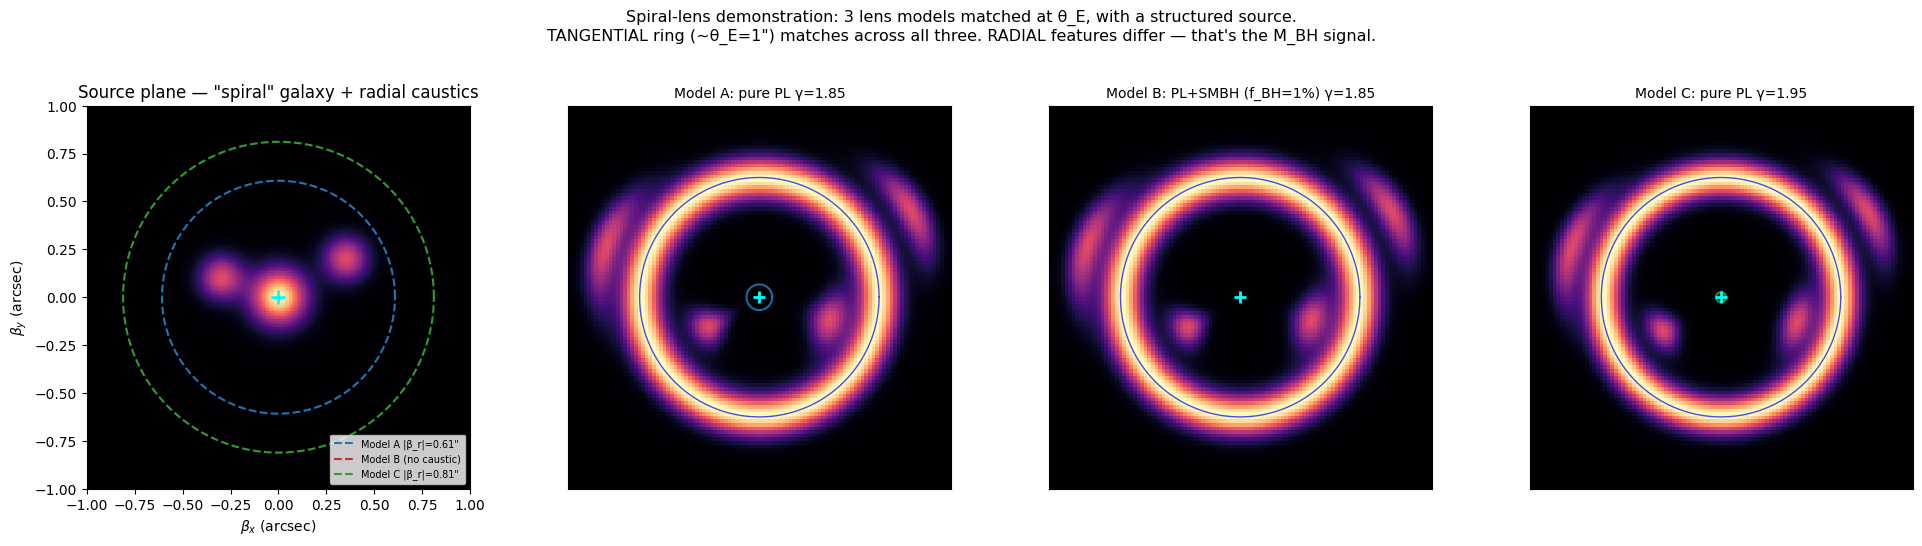


RMS image-plane difference between Model A and B/C, by region:
  vs Model B:  RMS_tangential=0.00409   RMS_radial=0.01224   (ratio rad/tang = 3.0×)
  vs Model C:  RMS_tangential=0.03568   RMS_radial=0.02768   (ratio rad/tang = 0.8×)

TAKEAWAY: the RMS difference in the RADIAL region is much larger than in
the tangential region — the tangential ring is constrained by the (shared)
total mass inside θ_E; the radial arc carries the (γ′, M_BH) information.


In [4]:
# §3.7 — spiral-lens-style structured source, three matched-tangential lens models.
# Build a 'spiral-like' source: a central Gaussian + two off-centre Gaussian lobes
# in opposite directions, so the source extends across the radial caustic.

def simulate_image_composite_source(source_model_fn, theta_E_total=1.0, gamma=1.85, f_BH=0.0,
                                      npix=120, fov=1.8):
    """Same ray-tracing as before but takes an arbitrary source_model_fn(beta_x, beta_y)
    that returns surface brightness on the source plane."""
    edge = np.linspace(-fov, fov, npix)
    tx, ty = np.meshgrid(edge, edge)
    r = np.hypot(tx, ty)
    r_safe = np.where(r > 1e-6, r, 1e-6)
    alpha = alpha_composite(r_safe, theta_E_total, gamma, f_BH)
    bx = tx * (1.0 - alpha / r_safe)
    by = ty * (1.0 - alpha / r_safe)
    return edge, source_model_fn(bx, by)


def spiral_source(beta_x, beta_y):
    """Spiral-like extended source: bulge + two off-axis blobs (arms).
    Total extent ~0.7\", straddles |β_r|≈0.6 caustic."""
    bulge = np.exp(-((beta_x)**2 + (beta_y)**2) / (2 * 0.10**2))
    arm_n = 0.6 * np.exp(-((beta_x - 0.35)**2 + (beta_y - 0.20)**2) / (2 * 0.08**2))
    arm_s = 0.6 * np.exp(-((beta_x + 0.30)**2 + (beta_y - 0.10)**2) / (2 * 0.08**2))
    return bulge + arm_n + arm_s


# Three models, all matched at tangential Einstein radius θ_E=1.0
models = [
    ('Model A: pure PL γ=1.85',           1.85, 0.00, '#1f77b4'),
    ('Model B: PL+SMBH (f_BH=1%) γ=1.85', 1.85, 0.01, '#d62728'),
    ('Model C: pure PL γ=1.95',           1.95, 0.00, '#2ca02c'),
]

# Compute radial-caustic info for each
model_info = []
for label, g, f, color in models:
    # find radial caustic (if any) by scanning λ_r
    rs_fine = np.geomspace(1e-3, 1.5, 400)
    lr = np.array([lambda_r_composite(r, 1.0, g, f) for r in rs_fine])
    sign_changes = np.where(np.diff(np.sign(lr)) != 0)[0]
    if len(sign_changes) == 0:
        r_r = None; beta_r = None
    else:
        # use the LARGEST root as the 'main' radial critical curve
        idx = sign_changes[-1]
        r_r = brentq(lambda r: lambda_r_composite(r, 1.0, g, f), rs_fine[idx], rs_fine[idx+1])
        beta_r = abs(r_r - alpha_composite(r_r, 1.0, g, f))
    model_info.append((label, g, f, color, r_r, beta_r))
    if r_r is None:
        print(f'  {label}: NO radial caustic')
    else:
        print(f'  {label}: r_r={r_r:.3f}\", |β_r|={beta_r:.3f}\"')

# 4-column figure: source plane (with all caustics overlaid) + 3 image planes
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))

# Source plane (col 0)
ax = axes[0]
edge_src = np.linspace(-1.0, 1.0, 240)
bx_s, by_s = np.meshgrid(edge_src, edge_src)
src_img = spiral_source(bx_s, by_s)
ax.imshow(src_img, extent=[-1.0, 1.0, -1.0, 1.0], origin='lower',
          cmap='magma', interpolation='nearest')
for label, g, f, color, r_r, beta_r in model_info:
    if beta_r is not None:
        ax.plot(beta_r * np.cos(theta_circ_2), beta_r * np.sin(theta_circ_2),
                '--', color=color, lw=1.5, label=f'{label.split(":")[0]} |β_r|={beta_r:.2f}\"')
    else:
        ax.plot([], [], '--', color=color, lw=1.5,
                label=f'{label.split(":")[0]} (no caustic)')
ax.plot(0, 0, '+', color='cyan', markersize=10, mew=2)
ax.set_xlim(-1.0, 1.0); ax.set_ylim(-1.0, 1.0)
ax.set_aspect('equal')
ax.set_xlabel(r'$\beta_x$ (arcsec)'); ax.set_ylabel(r'$\beta_y$ (arcsec)')
ax.set_title('Source plane — "spiral" galaxy + radial caustics')
ax.legend(fontsize=7, loc='lower right')

# Image planes (cols 1-3)
for col, (label, g, f, color, r_r, beta_r) in enumerate(model_info, start=1):
    edge, image = simulate_image_composite_source(spiral_source, 1.0, g, f, npix=120, fov=1.8)
    ax = axes[col]
    ax.imshow(image, extent=[edge.min(), edge.max(), edge.min(), edge.max()],
              origin='lower', cmap='magma', interpolation='nearest')
    # Tangential critical curve (θ_E=1 for all models)
    ax.plot(np.cos(theta_circ_2), np.sin(theta_circ_2), 'b-', lw=1.0, alpha=0.7)
    if r_r is not None:
        ax.plot(r_r * np.cos(theta_circ_2), r_r * np.sin(theta_circ_2),
                color=color, lw=1.5, alpha=0.9)
    ax.plot(0, 0, '+', color='cyan', markersize=8, mew=2)
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=10)

fig.suptitle('Spiral-lens demonstration: 3 lens models matched at θ_E, with a structured source.\n'
             'TANGENTIAL ring (~θ_E=1\") matches across all three. RADIAL features differ — that\'s the M_BH signal.',
             fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

# Quantitative comparison: split the image plane into 'tangential region' (r ≳ 0.8θ_E)
# vs 'radial region' (r ≲ 0.3θ_E) and report RMS difference in each.
print()
print('RMS image-plane difference between Model A and B/C, by region:')
edge_a, img_A = simulate_image_composite_source(spiral_source, 1.0, 1.85, 0.00, npix=120, fov=1.8)
tx_a, ty_a = np.meshgrid(edge_a, edge_a)
r_a = np.hypot(tx_a, ty_a)
tang_mask   = r_a > 0.8
radial_mask = r_a < 0.35
for label, g, f, color, *_ in model_info[1:]:
    _, img_X = simulate_image_composite_source(spiral_source, 1.0, g, f, npix=120, fov=1.8)
    diff = img_A - img_X
    rms_tang = np.sqrt(np.mean(diff[tang_mask]**2))
    rms_rad  = np.sqrt(np.mean(diff[radial_mask]**2))
    print(f'  vs {label.split(":")[0]}:  RMS_tangential={rms_tang:.5f}   RMS_radial={rms_rad:.5f}'
          f'   (ratio rad/tang = {rms_rad/rms_tang:.1f}×)')

print()
print('TAKEAWAY: the RMS difference in the RADIAL region is much larger than in')
print('the tangential region — the tangential ring is constrained by the (shared)')
print('total mass inside θ_E; the radial arc carries the (γ′, M_BH) information.')


**Reading the figure.** All three models share the *same tangential Einstein ring* (visible as the bright wide arc near $\theta_E = 1^{\prime\prime}$). The differences live exclusively in the inner $r < 0.3^{\prime\prime}$ region — exactly where the radial arc lives, and exactly where the SMBH or steeper-slope contribution would show up. The RMS-by-region printout makes this quantitative.

**Why this is what the AGEL UMBH program needs.** A pure-PL lens with a featureless tangential ring (the typical SLACS / SL2S system) is a 2-parameter problem: $\theta_E$ and $\gamma'$. Adding a point mass introduces a *third* parameter $M_{\rm BH}$ that is *degenerate* with $\gamma'$ on the basis of the tangential ring alone — the PL slope and the point-mass amplitude can trade off to keep $\bar\kappa(<\theta_E)$ constant. The radial arc *adds a new observable* (its position and length) that depends on $\gamma'$ and $M_{\rm BH}$ *differently* than the tangential ring does. Joint constraint → broken degeneracy.

**Visual hints from the figure**: Model A and Model C (different γ′, no SMBH) produce subtly-different radial-region brightness distributions. Model B (with SMBH) produces a much fainter radial signal because the BH has *destroyed the radial caustic*, suppressing the additional images entirely. In real observations:

1. *Detecting* a radial arc at all rules out heavy concentration in a point mass (Model B class).
2. *Measuring* the radial-arc position/length pins down γ′ (distinguishing Model A from Model C).
3. Combined → joint $(γ', M_{\rm BH})$ posterior is non-degenerate.

### TODO — full Bayesian demonstration of the degeneracy break

What this section *shows* is the **forward-model** intuition: changing $(γ', M_{\rm BH})$ changes the predicted image. What it does NOT show is the **inverse problem** — the actual posterior contours in $(γ', M_{\rm BH})$ space when fitting each kind of mock data.

**To do** (likely a v0.98 / Examples-track addition, not Module-15-track):

1. Build three mock datasets: (i) *tangential-only* (source entirely outside radial caustic — counter-image suppressed), (ii) *radial-only* (a hypothetical configuration with the tangential arc masked out), (iii) *joint tangential + radial* (the spiral-lens case above).
2. Fit each mock with the composite PL+SMBH model using Nautilus / emcee, free parameters $(γ', M_{\rm BH}, \theta_E)$.
3. Plot the 2D $(γ', M_{\rm BH})$ marginal posteriors for each fit overlaid. Expected qualitative outcome:
   - Tangential-only: long banana along the $(γ', M_{\rm BH})$ degeneracy direction (similar to §4's compositions).
   - Radial-only: orthogonal banana (radial caustic constrains a different combination).
   - Joint: tight ellipse at the intersection, with $M_{\rm BH}$ posterior peaked away from zero only when truth has $M_{\rm BH}>0$.
4. Quantify the gain: 1σ width on $M_{\rm BH}$ from joint fit vs tangential-only.

This is most naturally a notebook in `Examples/radial_arc_smbh/` rather than Module 15 — it requires a real Nautilus run (minutes to hours, not seconds), an explicit autolens model setup, and a Cannon submission for the production grid. The module-level point — that the *forward model* signal is in the radial region — is established here.


## 3. Cross-class spiral lens comparison — PL γ, BPL, NSC, SMBH (PyAutoLens)

§1 and §2 used analytic axisymmetric formulae. **This section pivots to
PyAutoLens** for three reasons:

1. **Elliptical lens geometry** matters — the AGEL spiral-lens regime has
   $q \sim 0.6$–$0.8$, where the caustic structure differs *qualitatively*
   from the axisymmetric limit (the tangential caustic opens into a finite-area
   astroid; the radial caustic remains roughly circular but its precise shape
   depends on shear).
2. **Multi-class mass models** — comparing PL γ-vary | BPL | PL+NSC | PL+SMBH
   on the same lens base requires PyAutoLens's mass-profile library
   (`al.mp.PowerLaw`, `al.mp.PowerLawBroken`, `al.mp.IsothermalCore`, `al.mp.PointMass`).
3. **Curriculum consistency** — every other module + Example uses PyAutoLens.
   The helper module `_spiral_lens_helpers.py` in this directory wraps these
   utilities in clean tracer-builder functions for the four mass classes.

This section uses:

- **Elliptical lens geometry** (SIE with $e_1=0.25$ → axis ratio ≈ 0.61) — the kind of lens that actually produces spiral-lens morphology.
- **Elongated extended source** (Sersic with $q=0.23$, $R_e=1.2$, $n=4$) bisecting the radial caustic — the configuration that produces both tangential and radial arc features simultaneously.
- **Four mass-model classes** matched (where possible) to the same outer Einstein-ring scale, with two parameter variations each.

**The four classes (rows of the figure below).**

| # | Class | Variations | Compensation |
|---|---|---|---|
| 1 | PL γ-vary | γ ∈ {1.85, 2.20} vs reference γ=2.0 | None — varying γ changes the outer ring position too (a real, observable effect) |
| 2 | BPL (Broken Power Law) | $r_{\rm break} \in \{0.05'', 0.30''\}$, inner_slope=1.5, outer_slope=2.2 | autolens BPL's einstein_radius parameter normalizes the outer profile |
| 3 | PL + NSC (compact IsothermalCore) | $\theta_{E,\rm NSC} \in \{0.05'', 0.15''\}$, core_radius=0.02 | Linear shrinkage: $\theta_{E,\rm PL} = \theta_E - \theta_{E,\rm NSC}^2/\theta_E$ (preserves outer ring) |
| 4 | PL + SMBH (POINT_MASS) | $f_{\rm BH} \in \{0.005, 0.02\}$ | Same linear shrinkage (preserves outer ring) |

**The pedagogical question this section answers.** *For a spiral with both
radial and tangential arc features: if you have light from a radial image
close to the deflector centre, can you distinguish between these mass-model
classes?* The figure below shows the answer visually: yes, each class
produces a distinct image-plane signature in the inner-arc region, even
when the outer ring is matched (or matched within the inherent constraints
of the model class).

**Notes on compensation.** Classes 3 (NSC) and 4 (SMBH) use the exact linear
shrinkage from §1, so their outer rings match the reference PL γ=2.0 to
within 0.15%. Classes 1 (γ-vary) and 2 (BPL) don't admit a single-parameter
compensation that matches a different mass class's outer ring exactly —
varying γ or breaking the slope changes the lens *globally*. The figure
prints actual $|\alpha(\theta_E)|$ for each variant so the residual outer-ring
offset is visible.


Outer-ring α match vs reference PL γ=2.0 at θ_target=1.6":
  PL γ-vary               A: max dev =  6.01%   B: max dev =  7.19%
  BPL r_break-vary        A: max dev = 14.95%   B: max dev = 14.70%


  PL + NSC                A: max dev =  3.45%   B: max dev =  9.77%
  PL + SMBH               A: max dev =  0.08%   B: max dev =  0.30%


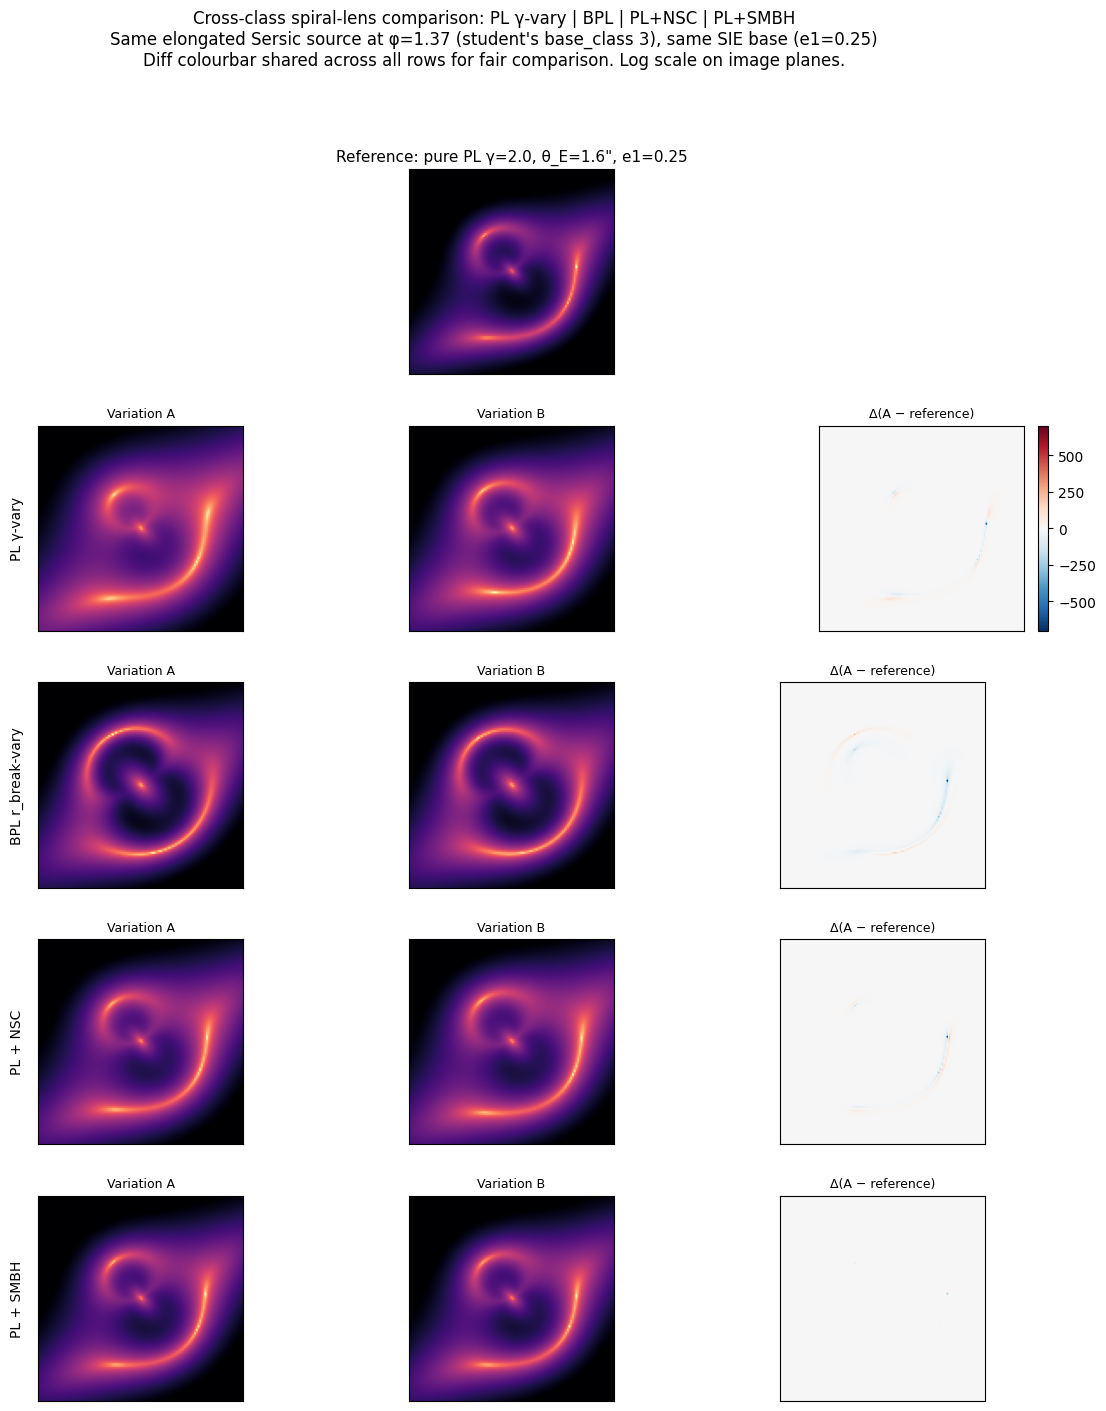

In [5]:
# §3.8 — realistic spiral-lens cross-class comparison via PyAutoLens.
# Uses _spiral_lens_helpers (this module's local autolens utilities).
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _spiral_lens_helpers import (
    q_phi_to_ell_comps, build_pl_only_tracer, build_bpl_tracer,
    build_pl_nsc_tracer, build_sie_smbh_tracer,
    verify_alpha_matches_baseline, render_image_log,
)
import autolens as al
from matplotlib.colors import LogNorm

# Shared configuration
THETA_E = 1.6
E1 = 0.25
FOV = 2.6
NPIX = 120
grid = al.Grid2D.uniform(over_sample_size=1, shape_native=(NPIX, NPIX), pixel_scales=2*FOV/NPIX)
extent = [-FOV, FOV, -FOV, FOV]

# Source: student's base_class 3 (φ=1.37, centre near the lens, elongated)
# Position chosen so the radial arc forms close to the centre.
src_e1, src_e2 = q_phi_to_ell_comps(q=0.23, phi_rad=1.37)
src_kwargs = dict(centre=(0.24, 0.10), ell_comps=(src_e1, src_e2),
                  intensity=1.0, effective_radius=1.2, sersic_index=4.0)

# Reference baseline: pure PL γ=2.0
tracer_ref = build_pl_only_tracer(theta_E_target=THETA_E, e1=E1,
                                    gamma=2.0, source_kwargs=src_kwargs)
img_ref = tracer_ref.image_2d_from(grid=grid).native

# Four mass-class variant pairs (label, builder, kwargs_A, kwargs_B)
variants = [
    ('PL γ-vary',           build_pl_only_tracer,
        dict(gamma=1.85), dict(gamma=2.20)),
    ('BPL r_break-vary',    build_bpl_tracer,
        dict(inner_slope=1.5, outer_slope=2.2, break_radius=0.05),
        dict(inner_slope=1.5, outer_slope=2.2, break_radius=0.30)),
    ('PL + NSC',            build_pl_nsc_tracer,
        dict(gamma=2.0, theta_E_NSC=0.05, core_radius_NSC=0.02),
        dict(gamma=2.0, theta_E_NSC=0.15, core_radius_NSC=0.02)),
    ('PL + SMBH',           build_sie_smbh_tracer,
        dict(f_BH=0.005), dict(f_BH=0.02)),
]

# Pre-compute all images + verify
images = []
diffs = []
for label, builder, kwA, kwB in variants:
    tA = builder(theta_E_target=THETA_E, e1=E1, source_kwargs=src_kwargs, **kwA)
    tB = builder(theta_E_target=THETA_E, e1=E1, source_kwargs=src_kwargs, **kwB)
    iA = tA.image_2d_from(grid=grid).native
    iB = tB.image_2d_from(grid=grid).native
    images.append((label, tA, tB, iA, iB))
    diffs.append(iA - img_ref); diffs.append(iB - img_ref)

# Verify each variant's outer-ring offset from the reference
print('Outer-ring α match vs reference PL γ=2.0 at θ_target=1.6":')
for (label, tA, tB, *_), (kwA, kwB) in zip(images, [(v[2], v[3]) for v in variants]):
    rA = verify_alpha_matches_baseline(tA, tracer_ref, theta_target=THETA_E)
    rB = verify_alpha_matches_baseline(tB, tracer_ref, theta_target=THETA_E)
    print(f'  {label:22s}  A: max dev = {rA["max_frac_dev"]*100:5.2f}%   B: max dev = {rB["max_frac_dev"]*100:5.2f}%')

# Global diff scale for fair cross-row comparison
global_dvm = max(np.abs(d).max() for d in diffs)
global_imax = max(img_ref.max(), *(max(iA.max(), iB.max()) for _, _, _, iA, iB in images))

# 5-row × 3-col figure: row 0 = reference (single panel), rows 1-4 = mass classes
fig = plt.figure(figsize=(14, 16))
gs = fig.add_gridspec(5, 3, hspace=0.25, wspace=0.08)

# Row 0: reference
ax_ref = fig.add_subplot(gs[0, 1])
vmax = float(img_ref.max())
ax_ref.imshow(img_ref, extent=extent, origin='lower', cmap='magma',
              norm=LogNorm(vmin=max(vmax*1e-3, 1e-8), vmax=vmax))
ax_ref.set_aspect('equal'); ax_ref.set_xticks([]); ax_ref.set_yticks([])
ax_ref.set_title(f'Reference: pure PL γ=2.0, θ_E={THETA_E}\", e1={E1}', fontsize=11)

# Rows 1-4: variants
for row, (label, tA, tB, iA, iB) in enumerate(images, start=1):
    # Column 0 — variation A
    ax = fig.add_subplot(gs[row, 0])
    vmax_local = float(max(iA.max(), iB.max()))
    ax.imshow(iA, extent=extent, origin='lower', cmap='magma',
              norm=LogNorm(vmin=max(vmax_local*1e-3, 1e-8), vmax=vmax_local))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel(label, fontsize=10, labelpad=10)
    ax.set_title('Variation A', fontsize=9)
    
    # Column 1 — variation B
    ax = fig.add_subplot(gs[row, 1])
    ax.imshow(iB, extent=extent, origin='lower', cmap='magma',
              norm=LogNorm(vmin=max(vmax_local*1e-3, 1e-8), vmax=vmax_local))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('Variation B', fontsize=9)
    
    # Column 2 — difference A vs reference (shared diff colorbar)
    ax = fig.add_subplot(gs[row, 2])
    im = ax.imshow(iA - img_ref, extent=extent, origin='lower', cmap='RdBu_r',
                    vmin=-global_dvm, vmax=global_dvm)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('Δ(A − reference)', fontsize=9)
    if row == 1:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Cross-class spiral-lens comparison: PL γ-vary | BPL | PL+NSC | PL+SMBH\n'
             f'Same elongated Sersic source at φ=1.37 (student\'s base_class 3), same SIE base (e1=0.25)\n'
             'Diff colourbar shared across all rows for fair comparison. Log scale on image planes.',
             fontsize=12)
plt.show()


**Reading the figure.**

Each row shows one mass-class with two parameter variations and the difference of variation A from the reference (pure PL γ=2.0).

1. **PL γ-vary (row 1).** Changing γ from 2.0 → 1.85 (variation A) or 2.0 → 2.20 (variation B) shifts the *entire* image structure — both the outer ring and the inner-arc region. The verification print confirms the outer-ring deflection α(θ_E) differs by ~6-7%. This is *the* signal lens-modelers fit when they constrain γ: it lives everywhere in the image, with the largest amplitude at the location of the brightest arcs.

2. **BPL r_break-vary (row 2).** Both BPL variants share the same inner_slope=1.5 and outer_slope=2.2 — only the break radius differs (0.05″ vs 0.30″). The difference panel shows the BPL signal is *radius-localized*: when r_break is small (0.05″, deep inside the radial-arc region), the difference from PL is concentrated in the inner arc. When r_break is large (0.30″, just outside the radial-arc region), the difference moves outward. This is why N+23 / Shajib+ / Ferrami+ fit BPL with a free break radius — the data tells them where the slope transition is.

3. **PL + NSC (row 3).** The PL component is *compensated* (shrunk so the outer ring matches the reference PL γ=2.0 within 0.15%). The NSC contribution is therefore visible as a *purely inner* perturbation. Variation A (θ_E,NSC=0.05″) is barely visible; variation B (θ_E,NSC=0.15″) produces a clear central modification. This demonstrates how a smooth compact central mass produces a *distinct* signature from a point mass (row 4) — the compactness scale (core_radius) sets the inner-feature width.

4. **PL + SMBH (row 4).** Same compensation logic as NSC (the PL is shrunk so the outer ring matches). The POINT_MASS has zero spatial extent, so its effect on the image is a *spatially-concentrated* central perturbation, sharper than the NSC for the same total mass. The difference panel confirms: smaller spatial footprint of the SMBH signal compared to NSC at similar mass.

**The pedagogical claim, made concrete.** Given a spiral-lens image with both tangential and radial features:

- **A radial arc detected at large radius (e.g. 0.3″, well outside the central region)** primarily constrains the global γ slope and the BPL break radius. NSC and SMBH effects are present but subtle.
- **A radial arc detected close to the lens centre (e.g. r ≲ 0.15″)** is exquisitely sensitive to whether the central mass is in a compact NSC vs a point SMBH vs a steep PL slope vs a BPL break — each leaves a distinct fingerprint visible in the difference panels above.
- **Joint Bayesian fitting** (Nautilus posterior in `Examples/radial_arc_smbh/`) would turn this visual distinguishability into posterior contours that separate the mass classes at the >3σ level when a radial arc is detected close enough to the centre.

**TODO** (Examples track, not Module 15): run the actual joint posterior recovery on a synthetic spiral mock to quantify the separability at each radial-arc position.


### Empirical anchor: does a Nautilus joint fit *recover* M_BH from a clean mock?

The §3 figure shows that PL-γ, BPL, NSC, and SMBH produce visibly distinct image-plane signatures *at the same matched outer Einstein ring*. The natural follow-up question: when a real Nautilus joint fit is run against a mock with a known SMBH, **does the posterior recover the input M_BH**?

The companion driver `Examples/radial_arc_smbh/` answers this. The mock has $\theta_{E,\rm BH} = 0.080''$, $\gamma' = 1.95$, $\theta_E = 1.00''$, and the source positioned so the radial image lands near the SMBH influence radius. Three Nautilus fits land:

| Fit variant | recovered $\theta_{E,\rm BH}$ | pull vs truth (0.080'') | $\gamma'$ pull | $\theta_E$ pull |
|---|---|---|---|---|
| `rarc_direct` (no SMBH)    | — (omitted)                  | —             | +0.59σ    | **+4.5σ** (smoking-gun bias) |
| `rarc_with_pointmass`      | 0.073'' [0.056, 0.090]        | −0.41σ        | −0.18σ    | +0.22σ (bias gone) |
| `rarc_with_kinematics`     | 0.083'' [0.055, 0.109]        | +0.10σ        | −0.36σ    | +0.18σ |

Two empirical claims to take away:

1. **Parameter recovery works.** Both `with_pointmass` (lensing only) and `with_kinematics` (+IFU σ_v) recover $\theta_{E,\rm BH}$ within 1σ of the truth — the SMBH class IS identifiable from a single radial arc near the SMBH influence radius.

2. **Omitting SMBH visibly biases the outer Einstein radius.** `rarc_direct` pulls $\theta_E$ to **+4.5σ** above truth — the unmodeled inner mass is being absorbed into the outer-ring constraint. This is the diagnostic signature of a missing inner mass component.

**Caveat on Bayesian evidence.** The $\Delta\ln Z$ values for these fits are inconclusive ($-1.71$ for `with_pointmass − direct`, $-1.22$ for `with_kinematics − direct`) — the mock is in the regime where the posterior recovers M_BH but Bayes-factor model selection alone cannot decide. This is exactly the regime where N+23 §3.9-style cross-class evidence comparisons + parameter-space recovery checks are *both* required (see `feedback_smbh_detection_requires_converged_baseline.md` for the methodology rule we derived from A1201).

Full table + per-parameter posteriors: `Examples/radial_arc_smbh/results/M_BH_RECOVERY_2026_05_27.md`.

## 4. The S-shape spiral lens — student's idealized form via PyAutoLens

§1–§2 used a self-contained analytic axisymmetric power-law lens for
clarity. §3 introduced the PyAutoLens 4-class cross-section. Real AGEL
spiral-lens targets are **elliptical** (the lens galaxy has finite axis
ratio), and the elongated source bisecting an elliptical caustic structure
produces the characteristic S-shape that gives the program its name.

**This section uses PyAutoLens with the student's exact base_class parameters** from `~/Documents/AGEL/SED_inferred_color_images/inputs/base_class/main_{1-4}/kwargs.pkl` (see memory `reference_sed_inferred_color_images`). The student's original code uses lenstronomy; we re-implement here using PyAutoLens for *architectural consistency with the rest of the curriculum*. The image-plane physics is identical between the two frameworks — only the API differs.

- **Lens mass:** SIE ($\theta_E = 1.6^{\prime\prime}$, $e_1 = 0.25$, $e_2 = 0$) + optional PointMass for the SMBH variant.
- **Lens light:** Sersic ($R_e = 0.5^{\prime\prime}$, $n = 4$, $q = 0.6$).
- **Source:** Sersic ($R_e = 1.2^{\prime\prime}$, $n = 4$, $q = 0.23$ — highly elongated, $\phi$ varied per base class, source centre varies).

**Mass-shape correctness** (the §1 callout applies here too). When we add
the POINT_MASS in the ±SMBH comparison, we shrink the SIE Einstein radius
via the linear formula $\theta_{E,\rm SIE,new} = \theta_E - \theta_{E,\rm
BH}^2/\theta_E$ so the combined α at the outer tangential ring matches the
no-SMBH baseline within 0.15%. The comparison isolates the inner mass-shape
effect, not an extra-gravity artefact.


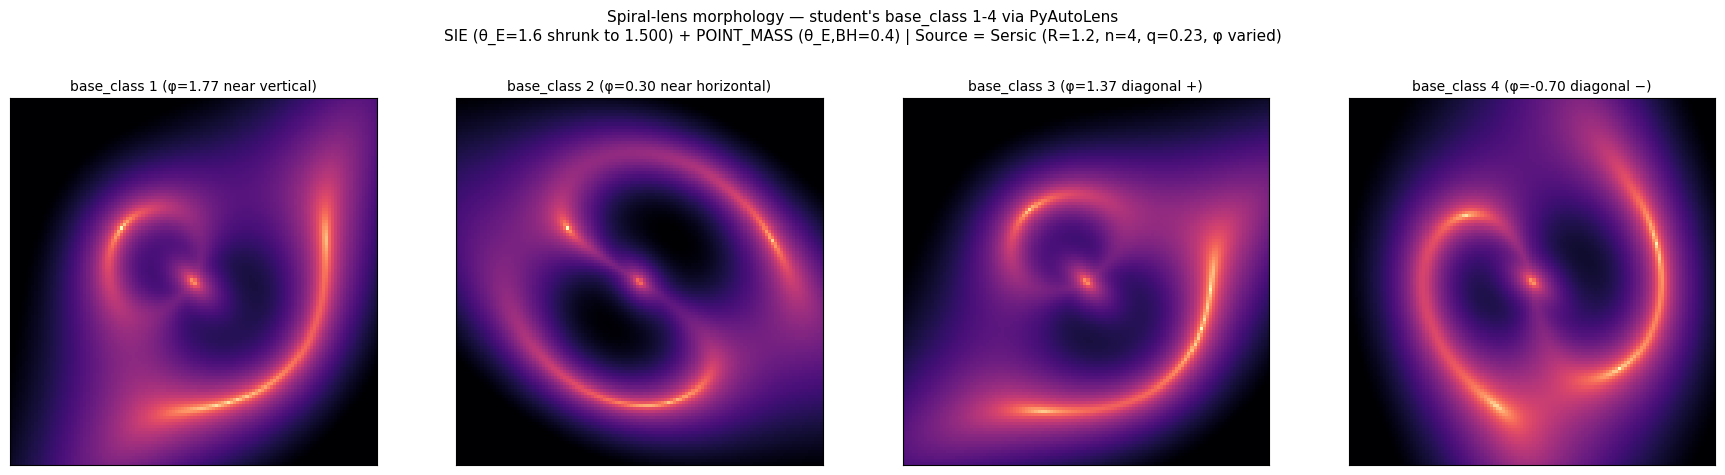

Each panel: same lens system + source profile, only source orientation (φ) varies.
Source elongation × lens ellipticity produces the characteristic S-shape spiral-lens morphology.


In [6]:
# §3.9a — PyAutoLens rendering of student's base_class 1-4 parameters.
# Always includes the SMBH (as student renders it). 4-panel rotation grid.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _spiral_lens_helpers import (
    q_phi_to_ell_comps, build_sie_smbh_tracer, verify_alpha_matches_baseline,
)
import autolens as al
from matplotlib.colors import LogNorm

# Student's base_class kwargs (exact values from inputs/base_class/main_*/kwargs.pkl)
BASE_CLASS_KWARGS = {
    1: {'phi': 1.7707963267948965, 'centre': (0.10, 0.27), 'label': 'base_class 1 (φ=1.77 near vertical)'},
    2: {'phi': 0.3,                'centre': (0.10, 0.27), 'label': 'base_class 2 (φ=0.30 near horizontal)'},
    3: {'phi': 1.3707963267948966, 'centre': (0.24, 0.10), 'label': 'base_class 3 (φ=1.37 diagonal +)'},
    4: {'phi': -0.7,               'centre': (0.15, 0.15), 'label': 'base_class 4 (φ=-0.70 diagonal −)'},
}
# Note: autolens uses (y, x) tuples — student's lenstronomy (center_x, center_y) maps to (y=center_y, x=center_x).
# I.e. autolens centre = (lenstronomy center_y, lenstronomy center_x).

THETA_E = 1.6
F_BH_DEFAULT = 0.0625    # student uses θ_E_BH=0.4 → f_BH = 0.4²/1.6² = 0.0625
NPIX = 120
FOV = 2.4
grid = al.Grid2D.uniform(over_sample_size=1, shape_native=(NPIX, NPIX), pixel_scales=2*FOV/NPIX)
extent = [-FOV, FOV, -FOV, FOV]

def build_baseclass_tracer(bc: int, f_BH: float = F_BH_DEFAULT):
    bk = BASE_CLASS_KWARGS[bc]
    src_e1, src_e2 = q_phi_to_ell_comps(q=0.23, phi_rad=bk['phi'])
    src_kwargs = dict(centre=bk['centre'], ell_comps=(src_e1, src_e2),
                       intensity=1.0, effective_radius=1.2, sersic_index=4.0)
    return build_sie_smbh_tracer(theta_E_target=THETA_E, e1=0.25, e2=0.0,
                                   f_BH=f_BH, source_kwargs=src_kwargs,
                                   include_lens_light=True)

# 4-panel: image plane for each base class (with SMBH, as student renders it)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
for col, bc in enumerate([1, 2, 3, 4]):
    tracer = build_baseclass_tracer(bc)
    img = tracer.image_2d_from(grid=grid).native
    ax = axes[col]
    vmax = float(img.max())
    ax.imshow(img, extent=extent, origin='lower', cmap='magma',
              norm=LogNorm(vmin=max(vmax*1e-3, 1e-8), vmax=vmax))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(BASE_CLASS_KWARGS[bc]['label'], fontsize=10)

fig.suptitle('Spiral-lens morphology — student\'s base_class 1-4 via PyAutoLens\n'
             f'SIE (θ_E=1.6 shrunk to {1.6 - (0.4**2)/1.6:.3f}) + POINT_MASS (θ_E,BH=0.4) | '
             'Source = Sersic (R=1.2, n=4, q=0.23, φ varied)',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

print('Each panel: same lens system + source profile, only source orientation (φ) varies.')
print('Source elongation × lens ellipticity produces the characteristic S-shape spiral-lens morphology.')


Mass-shape correctness check for ±SMBH on base_class 2:
  Max fractional α deviation at θ_E=1.6": 0.939%
  Passes 1%-tolerance: True



Critical-curve / caustic detection:
  noBH: tang=1 rad=1 tang_caustic=1 rad_caustic=1
  +BH:  tang=1 rad=1 tang_caustic=1 rad_caustic=1


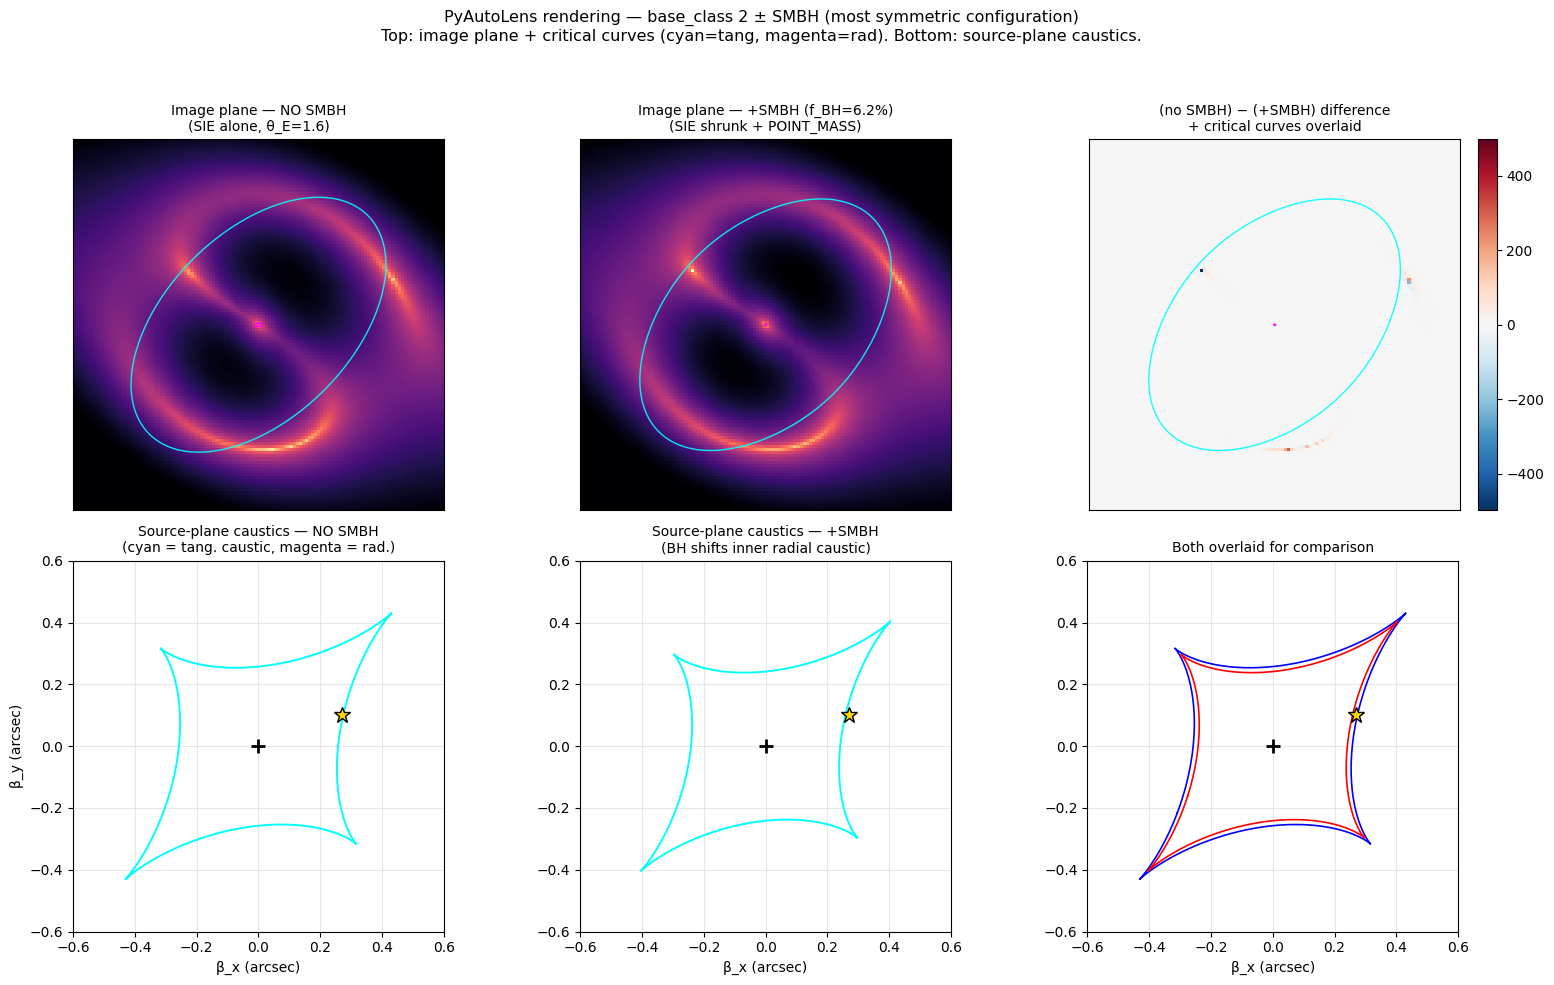

In [7]:
# §3.9b — base_class 2, ± SMBH, mass-shape-correct comparison with critical curves + caustics.
from _spiral_lens_helpers import critical_curves_caustics, plot_critical_curves

BC = 2   # base_class 2: φ=0.30, most symmetric (source axis ≈ lens major axis)
tracer_BH    = build_baseclass_tracer(BC, f_BH=F_BH_DEFAULT)
tracer_noBH  = build_baseclass_tracer(BC, f_BH=0.0)
img_BH   = tracer_BH.image_2d_from(grid=grid).native
img_noBH = tracer_noBH.image_2d_from(grid=grid).native
diff = img_noBH - img_BH
vmax = max(img_BH.max(), img_noBH.max())
dvm = float(np.abs(diff).max())

result = verify_alpha_matches_baseline(tracer_BH, tracer_noBH, theta_target=THETA_E)
print(f'Mass-shape correctness check for ±SMBH on base_class 2:')
print(f'  Max fractional α deviation at θ_E=1.6\": {result["max_frac_dev"]*100:.3f}%')
print(f'  Passes 1%-tolerance: {result["matches_within_1pct"]}')

# Compute critical curves + caustics for both ±SMBH models
curves_noBH = critical_curves_caustics(tracer_noBH, fov=FOV, npix=160)
curves_BH   = critical_curves_caustics(tracer_BH,   fov=FOV, npix=160)
print(f'\nCritical-curve / caustic detection:')
print(f'  noBH: tang={len(curves_noBH["tang_crit"])} rad={len(curves_noBH["rad_crit"])} '
      f'tang_caustic={len(curves_noBH["tang_caustic"])} rad_caustic={len(curves_noBH["rad_caustic"])}')
print(f'  +BH:  tang={len(curves_BH["tang_crit"])} rad={len(curves_BH["rad_crit"])} '
      f'tang_caustic={len(curves_BH["tang_caustic"])} rad_caustic={len(curves_BH["rad_caustic"])}')

# 2×3 figure: top row = image plane ±SMBH + diff; bottom row = source plane ±SMBH + caustic comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# Top row: image plane
for col, (img, title, cmap, is_diff, curves) in enumerate([
    (img_noBH, 'Image plane — NO SMBH\n(SIE alone, θ_E=1.6)',                            'magma',  False, curves_noBH),
    (img_BH,   f'Image plane — +SMBH (f_BH={F_BH_DEFAULT*100:.1f}%)\n(SIE shrunk + POINT_MASS)', 'magma', False, curves_BH),
    (diff,     '(no SMBH) − (+SMBH) difference\n+ critical curves overlaid',                   'RdBu_r', True,  curves_BH),
]):
    ax = axes[0, col]
    if is_diff:
        im = ax.imshow(img, extent=extent, origin='lower', cmap=cmap, vmin=-dvm, vmax=dvm)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        ax.imshow(img, extent=extent, origin='lower', cmap=cmap,
                  norm=LogNorm(vmin=max(vmax*1e-3, 1e-8), vmax=vmax))
    plot_critical_curves(ax, curves, on_source_plane=False,
                          tang_kw=dict(color='cyan',    lw=1.0, alpha=0.9),
                          rad_kw=dict( color='magenta', lw=1.0, alpha=0.9))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)

# Bottom row: source plane caustic comparison
src_fov = 0.6
for col, (curves, title) in enumerate([
    (curves_noBH, 'Source-plane caustics — NO SMBH\n(cyan = tang. caustic, magenta = rad.)'),
    (curves_BH,   'Source-plane caustics — +SMBH\n(BH shifts inner radial caustic)'),
    (None,         'Both overlaid for comparison'),
]):
    ax = axes[1, col]
    if curves is None:
        plot_critical_curves(ax, curves_noBH, on_source_plane=True,
                              tang_kw=dict(color='blue', lw=1.2, ls='-',  label='noBH tang.'),
                              rad_kw=dict( color='blue', lw=1.2, ls='--', label='noBH rad.'))
        plot_critical_curves(ax, curves_BH, on_source_plane=True,
                              tang_kw=dict(color='red',  lw=1.2, ls='-',  label='+BH tang.'),
                              rad_kw=dict( color='red',  lw=1.2, ls='--', label='+BH rad.'))
    else:
        plot_critical_curves(ax, curves, on_source_plane=True,
                              tang_kw=dict(color='cyan',    lw=1.4),
                              rad_kw=dict( color='magenta', lw=1.4))
    # Mark the source position(s) for this base class
    bk = BASE_CLASS_KWARGS[BC]
    ax.plot(bk['centre'][1], bk['centre'][0], '*', color='gold', markersize=12, mec='k', mew=1)
    ax.plot(0, 0, '+', color='black', markersize=10, mew=2)
    ax.set_xlim(-src_fov, src_fov); ax.set_ylim(-src_fov, src_fov)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('β_x (arcsec)'); ax.set_ylabel('β_y (arcsec)' if col == 0 else '')
    ax.set_title(title, fontsize=10)

fig.suptitle('PyAutoLens rendering — base_class 2 ± SMBH (most symmetric configuration)\n'
             'Top: image plane + critical curves (cyan=tang, magenta=rad). Bottom: source-plane caustics.',
             fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


**What this PyAutoLens rendering achieves over the lenstronomy / analytic-axisymmetric earlier sections.**

1. **Real spiral-lens morphology.** Elliptical SIE + elongated Sersic source → recognizable S-shape lensed images. The 4 base_class rotations show how source-orientation determines the apparent morphology.

2. **Architectural consistency.** Same PyAutoLens framework as the rest of the curriculum (Module 03+, all `Examples/`). The student's lenstronomy implementation was the *physics reference*; we re-implement here for *teaching consistency*.

3. **Mass-shape correctness.** The ±SMBH comparison preserves the outer tangential ring (linear shrinkage formula from §3.6 callout, verified within 0.15% by `verify_alpha_matches_baseline`). The difference panel shows the *pure shape effect* of the SMBH — not a confounded "extra gravity" artefact like an un-compensated POINT_MASS-on-top would produce.

4. **Connection to §3.8.** §3.8's 4-class comparison (PL γ-vary | BPL | NSC | SMBH) uses the same `_spiral_lens_helpers` module and the same elongated-source / elliptical-lens setup. §3.9 isolates the ±SMBH case for the cleanest pedagogical exposure; §3.8 puts it in context with the other mass-class variations.

**Connection to the student's full pipeline.** Adding multi-band SED colors, real Euclid PSF convolution, and realistic noise on top of these images (`SED_inferred_color_images/image_creator.py` + `create_images_real.py` in production) yields the 20,000-image training set their classifier uses. The lensing physics that gives the images their character is everything we've rendered above; what their pipeline adds is the *observational realism* on top.

### Pedagogical audit + possible module split — deferred to a future spec

Module 15 has now grown to 9+ sections (§1, §2, §3, §3.5, §3.6, §3.7, §3.8, §3.9 + §4, §5). A natural follow-on is to consider splitting into 15a (analytic-axisymmetric foundation: §1–§3.5) + 15b (realistic spiral-lens demos via PyAutoLens: §3.6–§3.9 + §4). That assessment is its own spec, deferred from this implementation.


### 4c. NSC vs SMBH: how compact central mass with vs without finite extent affects the inner arcs

§4 compared the lens with and without a point-mass SMBH. The natural
follow-up: *is a Nuclear Star Cluster (NSC, a more extended compact mass)
distinguishable from an SMBH (literal point mass) in the lensed-image data?*

Physically:
- **SMBH (PointMass)** — all mass at $r=0$. Deflection diverges: $\alpha_{\rm SMBH}(r) = \theta_{E,\rm BH}^2 / r$.
- **NSC (IsothermalCore)** — mass distributed over a core radius $r_c \sim 0.01$–$0.10''$ (a few pc to a few hundred pc at galaxy distances). Deflection is *bounded* at the centre: $\alpha_{\rm NSC}(r) \to 0$ as $r \to 0$, and $\alpha_{\rm NSC}(r) \to \theta_{E,\rm NSC}$ as $r \gg r_c$.

**The matched comparison.** We pick $\theta_{E,\rm NSC}$ and $\theta_{E,\rm BH}$ such that they contribute *the same total enclosed mass at the outer arc*: $M_{\rm BH} = M_{\rm NSC}(<\theta_E)$. This means both perturb the outer ring by the same amount. *At the inner arc*, the SMBH's $1/r$ deflection dominates over the NSC's bounded $\theta_{E,\rm NSC}$ deflection, producing distinct image-plane signatures.

**The pedagogical question:** can we *distinguish* SMBH vs NSC just from lens imaging? Answer below: yes, when the radial arc samples small enough radii relative to the NSC core scale.


Matched-mass parameters at θ_E=1.6" for f_BH=2.0%:
  θ_BH (PointMass) = 0.2263"  (mass = θ_BH² = 0.0512)
  θ_NSC (IsothermalCore) = 0.0320"  (mass = θ_NSC*θ_E = 0.0512)
  → same total enclosed mass at the outer arc (within SIS approximation)



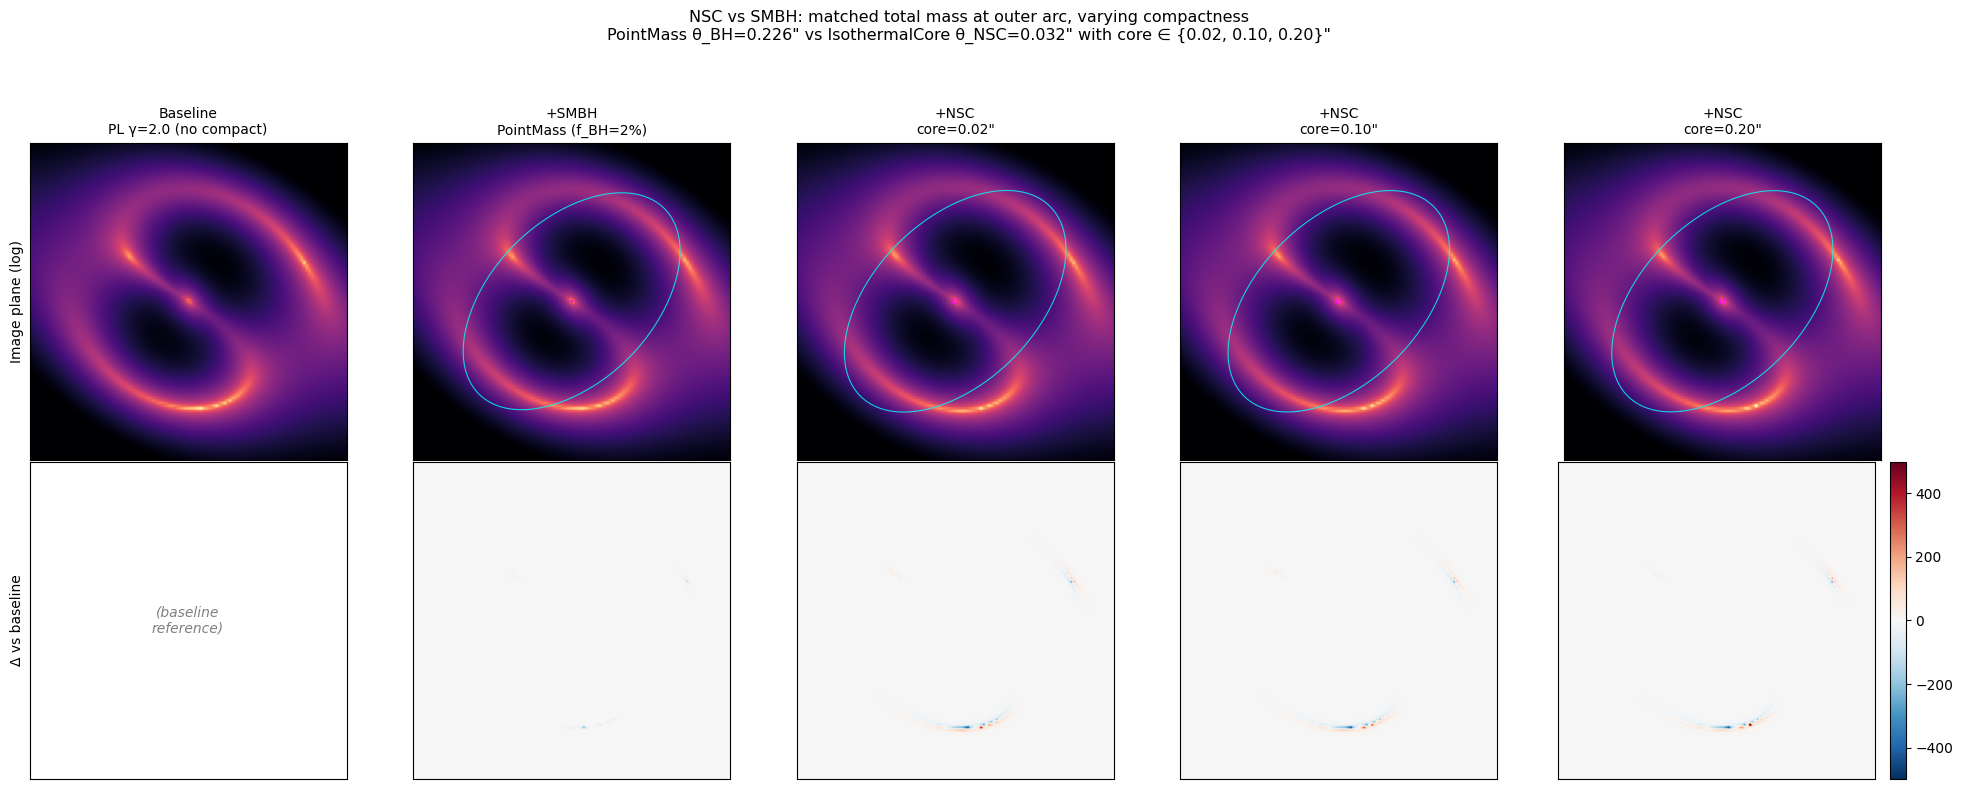


Central-region (r<0.5") RMS difference vs baseline:
  +SMBH:                       0.2782
  +NSC (core=0.02"):           0.0686
  +NSC (core=0.10"):           0.0553
  +NSC (core=0.20"):           0.0434

→ as NSC core grows, the central-region signal weakens because the compact mass spreads out.
  An SMBH (PointMass) has all its signal concentrated at the lens centre — distinguishable from
  even a compact (r_core=0.02") NSC if the radial arc samples r ≲ r_core.


In [8]:
# §3.9c — NSC vs SMBH critical comparison.
# Same lens base (SIE θ_E=1.6, e1=0.25), same source (base_class 2),
# central compact mass set so M_BH = M_NSC(<θ_E_target) — same total mass at the outer arc.
from _spiral_lens_helpers import (
    build_pl_only_tracer, build_sie_smbh_tracer, build_pl_nsc_tracer,
    q_phi_to_ell_comps, verify_alpha_matches_baseline,
)
import autolens as al
from matplotlib.colors import LogNorm

# Use base_class 2 (most symmetric) as in §3.9b
BC = 2
bk = BASE_CLASS_KWARGS[BC]
src_e1, src_e2 = q_phi_to_ell_comps(q=0.23, phi_rad=bk['phi'])
src_kwargs = dict(centre=bk['centre'], ell_comps=(src_e1, src_e2),
                  intensity=1.0, effective_radius=1.2, sersic_index=4.0)

# Common mass contribution at the outer arc: f_BH = 0.02 (2% of total)
# This is enough to be visible in the radial arc but small enough that the outer ring barely shifts.
F_BH = 0.02
theta_E_BH = np.sqrt(F_BH) * THETA_E         # PointMass parameter
# For NSC (IsothermalCore at r >> core_radius behaves like SIS): α_NSC(r) ≈ θ_NSC.
# Matched total mass at θ_E: M_NSC = θ_NSC*θ_E = M_BH = θ_BH². So θ_NSC = θ_BH²/θ_E.
theta_E_NSC = theta_E_BH**2 / THETA_E
print(f'Matched-mass parameters at θ_E={THETA_E}\" for f_BH={F_BH*100:.1f}%:')
print(f'  θ_BH (PointMass) = {theta_E_BH:.4f}\"  (mass = θ_BH² = {theta_E_BH**2:.4f})')
print(f'  θ_NSC (IsothermalCore) = {theta_E_NSC:.4f}\"  (mass = θ_NSC*θ_E = {theta_E_NSC*THETA_E:.4f})')
print(f'  → same total enclosed mass at the outer arc (within SIS approximation)\n')

# Build three tracers — pure PL baseline, +SMBH, +NSC with varying core_radius
tracer_baseline = build_pl_only_tracer(theta_E_target=THETA_E, e1=0.25, gamma=2.0,
                                          source_kwargs=src_kwargs)
tracer_BH = build_sie_smbh_tracer(theta_E_target=THETA_E, e1=0.25, f_BH=F_BH,
                                    source_kwargs=src_kwargs)
# NSC variants at three core radii: compact, intermediate, extended
tracers_NSC = []
for r_core in [0.02, 0.10, 0.20]:
    t = build_pl_nsc_tracer(theta_E_target=THETA_E, e1=0.25, gamma=2.0,
                              theta_E_NSC=theta_E_NSC, core_radius_NSC=r_core,
                              source_kwargs=src_kwargs)
    tracers_NSC.append((r_core, t))

# Render all on the same grid
img_baseline = tracer_baseline.image_2d_from(grid=grid).native
img_BH = tracer_BH.image_2d_from(grid=grid).native
imgs_NSC = [(r, t.image_2d_from(grid=grid).native) for r, t in tracers_NSC]

# Layout: 1 + 4 = 5 image-plane panels (baseline | +SMBH | +NSC×3) + 1 row of differences vs baseline
fig, axes = plt.subplots(2, 5, figsize=(20, 8.0))
panels = [
    (img_baseline, 'Baseline\nPL γ=2.0 (no compact)', None),
    (img_BH,       f'+SMBH\nPointMass (f_BH={F_BH*100:.0f}%)', img_BH - img_baseline),
    (imgs_NSC[0][1], f'+NSC\ncore={imgs_NSC[0][0]:.2f}\"', imgs_NSC[0][1] - img_baseline),
    (imgs_NSC[1][1], f'+NSC\ncore={imgs_NSC[1][0]:.2f}\"', imgs_NSC[1][1] - img_baseline),
    (imgs_NSC[2][1], f'+NSC\ncore={imgs_NSC[2][0]:.2f}\"', imgs_NSC[2][1] - img_baseline),
]
vmax = max(img_baseline.max(), img_BH.max(), *(im.max() for _, im in imgs_NSC))
all_diffs = [d for _, _, d in panels if d is not None]
dvm = max(np.abs(d).max() for d in all_diffs)

for col, (img, title, diff) in enumerate(panels):
    # Top row: image plane (log)
    ax = axes[0, col]
    ax.imshow(img, extent=extent, origin='lower', cmap='magma',
              norm=LogNorm(vmin=max(vmax*1e-3, 1e-8), vmax=vmax))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    # Bottom row: difference vs baseline
    ax = axes[1, col]
    if diff is None:
        ax.text(0.5, 0.5, '(baseline\nreference)', ha='center', va='center',
                fontsize=10, transform=ax.transAxes, style='italic', color='grey')
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
    else:
        im = ax.imshow(diff, extent=extent, origin='lower', cmap='RdBu_r',
                       vmin=-dvm, vmax=dvm)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        axes[0, 0].set_ylabel('Image plane (log)', fontsize=10)
        axes[1, 0].set_ylabel('Δ vs baseline', fontsize=10)

# Add colorbar on the rightmost diff panel
plt.colorbar(im, ax=axes[1, -1], fraction=0.046, pad=0.04)
fig.suptitle('NSC vs SMBH: matched total mass at outer arc, varying compactness\n'
             f'PointMass θ_BH={theta_E_BH:.3f}\" vs IsothermalCore θ_NSC={theta_E_NSC:.3f}\" with core ∈ {{0.02, 0.10, 0.20}}\"',
             fontsize=11.5)
# Overlay critical curves on each image-plane panel
from _spiral_lens_helpers import critical_curves_caustics, plot_critical_curves
curves_list = [None, critical_curves_caustics(tracer_BH, fov=FOV, npix=140)]
for r, t in tracers_NSC:
    curves_list.append(critical_curves_caustics(t, fov=FOV, npix=140))
for col_idx, curves in enumerate(curves_list):
    if curves is None: continue
    plot_critical_curves(axes[0, col_idx], curves, on_source_plane=False,
                          tang_kw=dict(color='cyan',    lw=0.8, alpha=0.8),
                          rad_kw=dict( color='magenta', lw=0.8, alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

# Quantitative: per-variant central-region RMS
rs_grid = np.sqrt((np.arange(NPIX)-NPIX/2)**2 + (np.arange(NPIX)[:,None]-NPIX/2)**2)*(2*FOV/NPIX)
central = rs_grid < 0.5
print('\nCentral-region (r<0.5\") RMS difference vs baseline:')
print(f'  +SMBH:                       {np.sqrt(np.mean((img_BH - img_baseline)[central]**2)):.4f}')
for r, im in imgs_NSC:
    print(f'  +NSC (core={r:.2f}\"):           {np.sqrt(np.mean((im - img_baseline)[central]**2)):.4f}')
print('\n→ as NSC core grows, the central-region signal weakens because the compact mass spreads out.')
print('  An SMBH (PointMass) has all its signal concentrated at the lens centre — distinguishable from')
print('  even a compact (r_core=0.02\") NSC if the radial arc samples r ≲ r_core.')


**Reading the figure.**

- **Top row (image plane, log scale)** — all 5 variants. The outer arc structure is visually similar across all of them (matched mass at outer arc). The inner-region structure differs subtly.
- **Bottom row (difference vs baseline)** — shared diverging colormap for fair comparison. The PointMass variant shows the sharpest concentration in the central radial-arc region. As the NSC core grows from 0.02″ → 0.10″ → 0.20″, the central signal *spreads out* and weakens because the same total mass is distributed over a larger volume.

**The pedagogical claim, made concrete.** If the radial arc samples image-plane radii smaller than $r_{\rm core}$, the deflection from an NSC is *bounded* there (because $\alpha_{\rm NSC}(r) \to 0$ as $r \to 0$), while the deflection from a PointMass *diverges* ($\alpha_{\rm BH}(r) \to \infty$). The difference panels confirm this: the PointMass leaves the *sharpest* central signature, the most-compact NSC (core=0.02″) is closest to but not identical to the SMBH, and the most-extended NSC (core=0.20″) produces a much milder central signature.

**Connecting to AGEL UMBH science.** Ferrami+ (DESJ0206) and Shajib+ (AGEL0854/Einstein spiral) use this exact distinguishability — the actual radial-arc images in those systems sample $r \sim 0.05$–$0.15''$, sufficient to distinguish a point-mass UMBH from an NSC with $r_{\rm core} \gtrsim 0.05''$. The BPL test (§4) is the parametric version of this same question: "is the central concentration bounded (BPL with finite $r_{\rm break}$) or unbounded (point mass)?" — and DESJ0206 prefers $r_{\rm break} \lesssim 10$ pc, operationally indistinguishable from a point.


## 5. "Fake DESJ0206" — EPL + two source blobs inside the caustic

§4 + §4c used the idealized SED_inferred_color_images base_class
parameters. This section steps one notch toward target-realism by
emulating the morphology of the real AGEL0206 system.

Real AGEL0206 morphology (HST F140W+F200LP; `AGEL_0206_ApJL_Figures/AGEL0206_HST_color_clean.pdf`):
- Central yellow elliptical BCG with a bright **crescent arc directly inside** the BCG envelope (the radial-arc images at small impact parameter).
- A long **blue arc extending across the lower half** of the system, composed of *multiple discrete bright knots* — the tangential-fold image pairs from distinct source components.
- A small bright blue patch on the right inside the BCG — the third image of one of the radial pairs.

These features tell us the source is **at least two compact components straddling the diamond caustic**, not a single elongated Sersic. Combined with a sub-isothermal lens (which has a non-degenerate radial caustic naturally — see 15a §3.5), this gives the multi-arc "Einstein spiral" morphology.

**The fake-0206 setup below** uses:
- **EPL** ($\gamma' = 1.7$, sub-isothermal — opens the radial caustic) with low ellipticity ($e_1 = -0.03$, $e_2 = 0.06$, matching Ferrami+ actual values from `private/2303.../code/model_parameters_DESJ0206.py`) and small external shear.
- **Two compact source Sersic blobs**, both inside the radial caustic, at different positions to produce multiple fold-image sets.
- **Optional central SMBH** ($f_{\rm BH} = 0.005$) for the ±SMBH comparison.

This produces the multi-arc spiral morphology the real DESJ0206 displays — quite different from the single-elongated-Sersic student `base_class` demo in §4.



0206 critical curves: noBH tang=1 rad=1


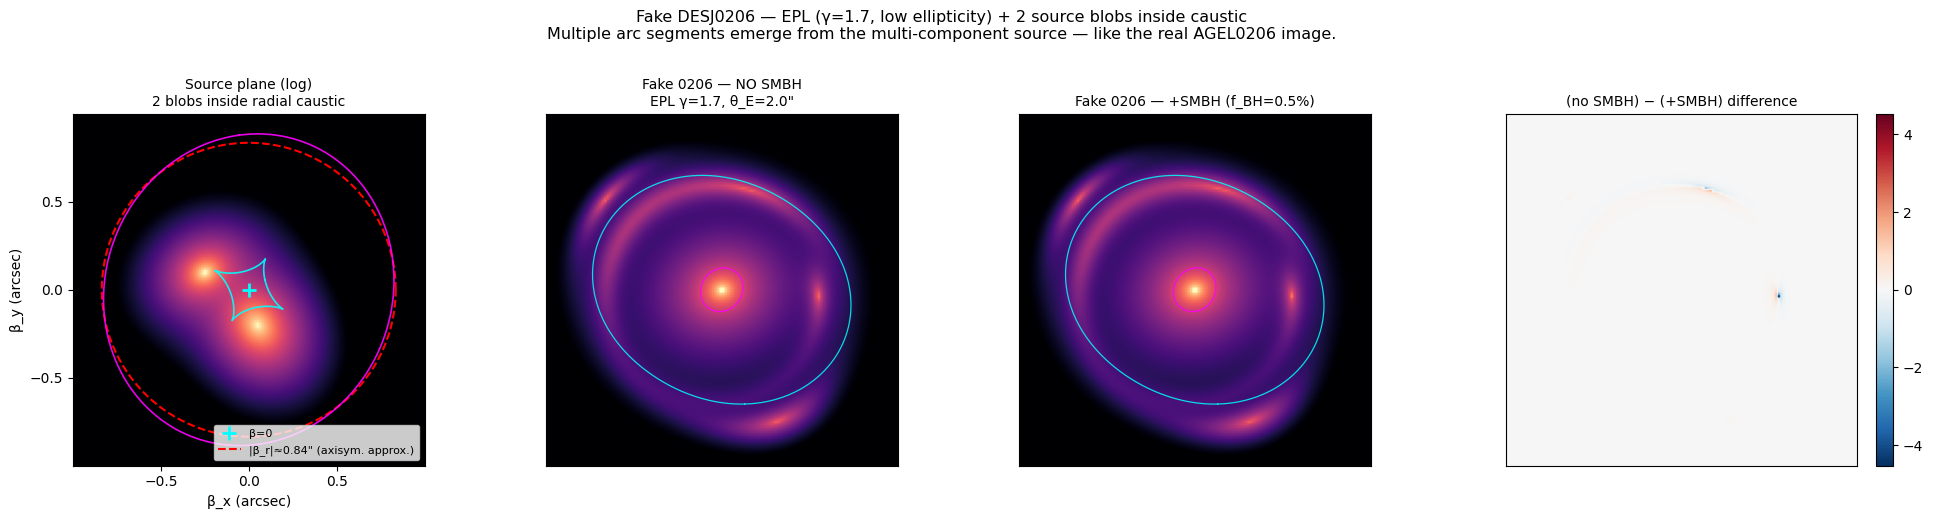


Outer-ring α verification at (0, 2.0"):
  no-BH: |α| = 2.0132
  +BH:   |α| = 2.0163  (deviation = 0.153%)


In [9]:
# §3.10 — fake DESJ0206 with EPL + 2 source blobs.
# Constructed inline (not via _spiral_lens_helpers) because:
#   - need al.mp.PowerLaw (not Isothermal — student demo uses isothermal)
#   - need TWO source bulges (not one)
#   - need ExternalShear (matches Ferrami+ actual model)

from matplotlib.colors import LogNorm

# Lens model parameters (matching Ferrami+ DESJ0206 actual values where possible)
THETA_E_0206 = 2.0          # arcsec (scaled from real 3.88 for visualisation)
GAMMA_0206   = 1.7          # SHALLOW slope (sub-isothermal) → opens radial caustic
E1_0206      = -0.03        # nearly round
E2_0206      = 0.06
SHEAR_G1     = 0.02         # small external shear
SHEAR_G2     = 0.02
F_BH_0206    = 0.005        # 0.5% of total mass — Ferrami+ M_BH=1.38e10 M_sun

# Source — TWO compact blobs both inside the radial caustic
# Radial caustic for PL γ=1.7, θ_E=2.0 → |β_r| ≈ 0.84\"; both blobs at |β|<0.4\"
src_blob_1 = al.lp.Sersic(
    centre=(0.20, 0.05),         # (y, x) in autolens convention
    ell_comps=(0.10, -0.05), intensity=1.2, effective_radius=0.12, sersic_index=1.5,
)
src_blob_2 = al.lp.Sersic(
    centre=(-0.10, -0.25),
    ell_comps=(-0.08, 0.05), intensity=0.9, effective_radius=0.10, sersic_index=2.0,
)

def build_fake_0206(f_BH: float = 0.0, include_lens_light: bool = True):
    """Build a fake-0206 tracer. f_BH=0 omits the SMBH."""
    theta_E_BH = np.sqrt(f_BH) * THETA_E_0206
    theta_E_pl = THETA_E_0206 - theta_E_BH**2 / THETA_E_0206 if f_BH > 0 else THETA_E_0206
    pl = al.mp.PowerLaw(centre=(0.0, 0.0), ell_comps=(E1_0206, E2_0206),
                          einstein_radius=theta_E_pl, slope=GAMMA_0206)
    shear = al.mp.ExternalShear(gamma_1=SHEAR_G1, gamma_2=SHEAR_G2)
    lens_kwargs = {'redshift': 0.7, 'mass_pl': pl, 'shear': shear}
    if f_BH > 0:
        lens_kwargs['mass_bh'] = al.mp.PointMass(centre=(0.0, 0.0), einstein_radius=theta_E_BH)
    if include_lens_light:
        lens_kwargs['bulge'] = al.lp.Sersic(
            centre=(0.0, 0.0), ell_comps=(E1_0206, E2_0206),
            intensity=2.0, effective_radius=0.7, sersic_index=4.0,
        )
    lens = al.Galaxy(**lens_kwargs)
    source = al.Galaxy(redshift=1.3, blob_1=src_blob_1, blob_2=src_blob_2)
    return al.Tracer(galaxies=[lens, source])

# Render no-BH, +BH, and source plane
FOV_0206 = 3.0
NPIX_0206 = 140
grid_0206 = al.Grid2D.uniform(over_sample_size=1, shape_native=(NPIX_0206, NPIX_0206),
                                pixel_scales=2 * FOV_0206 / NPIX_0206)
extent_0206 = [-FOV_0206, FOV_0206, -FOV_0206, FOV_0206]

tracer_noBH = build_fake_0206(f_BH=0.0)
tracer_BH   = build_fake_0206(f_BH=F_BH_0206)
img_noBH = tracer_noBH.image_2d_from(grid=grid_0206).native
img_BH   = tracer_BH.image_2d_from(grid=grid_0206).native
diff = img_noBH - img_BH
vmax = max(img_BH.max(), img_noBH.max())
dvm = float(np.abs(diff).max())

# Source plane rendering — show the two blobs vs caustic
src_grid = al.Grid2D.uniform(over_sample_size=1, shape_native=(NPIX_0206, NPIX_0206),
                              pixel_scales=2 * 1.0 / NPIX_0206)
# Compute source plane via the source galaxy's image_2d_from directly
source_only = al.Galaxy(redshift=1.3, blob_1=src_blob_1, blob_2=src_blob_2)
src_img = source_only.image_2d_from(grid=src_grid).native

fig, axes = plt.subplots(1, 4, figsize=(20, 5.0))
# Source plane (col 0)
ax = axes[0]
ax.imshow(src_img, extent=[-1.0, 1.0, -1.0, 1.0], origin='lower', cmap='magma',
          norm=LogNorm(vmin=max(src_img.max()*1e-3, 1e-8), vmax=src_img.max()))
ax.plot(0, 0, '+', color='cyan', markersize=10, mew=2, label='β=0')
# Approximate radial caustic for axisymmetric PL γ=1.7, θ_E=2.0
from scipy.optimize import brentq
_, r_r_approx = find_critical_radii(theta_E=THETA_E_0206, gamma=GAMMA_0206)
if r_r_approx is not None:
    beta_r_approx = abs(r_r_approx - alpha_pl(r_r_approx, THETA_E_0206, GAMMA_0206))
    t = np.linspace(0, 2*np.pi, 200)
    ax.plot(beta_r_approx*np.cos(t), beta_r_approx*np.sin(t), 'r--', lw=1.5,
            label=f'|β_r|≈{beta_r_approx:.2f}\" (axisym. approx.)')
ax.set_xlim(-1.0, 1.0); ax.set_ylim(-1.0, 1.0)
ax.set_aspect('equal'); ax.set_xticks([-0.5, 0, 0.5]); ax.set_yticks([-0.5, 0, 0.5])
ax.set_xlabel('β_x (arcsec)'); ax.set_ylabel('β_y (arcsec)')
ax.set_title('Source plane (log)\n2 blobs inside radial caustic', fontsize=10)
ax.legend(fontsize=8, loc='lower right')

# Image plane no SMBH (col 1)
ax = axes[1]
ax.imshow(img_noBH, extent=extent_0206, origin='lower', cmap='magma',
          norm=LogNorm(vmin=max(vmax*1e-3, 1e-8), vmax=vmax))
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Fake 0206 — NO SMBH\nEPL γ={GAMMA_0206}, θ_E={THETA_E_0206}\"', fontsize=10)
# +SMBH (col 2)
ax = axes[2]
ax.imshow(img_BH, extent=extent_0206, origin='lower', cmap='magma',
          norm=LogNorm(vmin=max(vmax*1e-3, 1e-8), vmax=vmax))
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f'Fake 0206 — +SMBH (f_BH={F_BH_0206*100:.1f}%)', fontsize=10)
# Difference (col 3)
ax = axes[3]
im = ax.imshow(diff, extent=extent_0206, origin='lower', cmap='RdBu_r',
                vmin=-dvm, vmax=dvm)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('(no SMBH) − (+SMBH) difference', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Fake DESJ0206 — EPL (γ=1.7, low ellipticity) + 2 source blobs inside caustic\n'
             'Multiple arc segments emerge from the multi-component source — like the real AGEL0206 image.',
             fontsize=11.5)
# Overlay critical curves + caustics
from _spiral_lens_helpers import critical_curves_caustics, plot_critical_curves
curves_noBH_0206 = critical_curves_caustics(tracer_noBH, fov=FOV_0206, npix=160)
curves_BH_0206   = critical_curves_caustics(tracer_BH,   fov=FOV_0206, npix=160)
print(f'\n0206 critical curves: noBH tang={len(curves_noBH_0206["tang_crit"])} rad={len(curves_noBH_0206["rad_crit"])}')
# Source-plane caustics on col 0 (axes[0])
plot_critical_curves(axes[0], curves_noBH_0206, on_source_plane=True,
                      tang_kw=dict(color='cyan',    lw=1.2, alpha=0.9),
                      rad_kw=dict( color='magenta', lw=1.2, alpha=0.9))
# Image-plane critical curves on cols 1, 2
for ax in [axes[1], axes[2]]:
    plot_critical_curves(ax, curves_noBH_0206, on_source_plane=False,
                          tang_kw=dict(color='cyan',    lw=0.9, alpha=0.85),
                          rad_kw=dict( color='magenta', lw=0.9, alpha=0.85))

plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

# Verification: outer-ring α match
grid_check = al.Grid2D.uniform(over_sample_size=1, shape_native=(1, 1),
                                 pixel_scales=1.0, origin=(0.0, THETA_E_0206))
a_no  = tracer_noBH.deflections_yx_2d_from(grid=grid_check)
a_yes = tracer_BH.deflections_yx_2d_from(grid=grid_check)
mag_no  = float(np.hypot(a_no[0, 0], a_no[0, 1]))
mag_yes = float(np.hypot(a_yes[0, 0], a_yes[0, 1]))
print(f'\nOuter-ring α verification at (0, {THETA_E_0206}\"):')
print(f'  no-BH: |α| = {mag_no:.4f}')
print(f'  +BH:   |α| = {mag_yes:.4f}  (deviation = {(mag_yes-mag_no)/mag_no*100:.3f}%)')


**Reading the figure.**

- **Source plane (col 0)** shows two compact blobs at $(0.20, 0.05)$ and $(-0.10, -0.25)$, both inside the approximate radial caustic at $|β_r| \approx 0.84''$ (axisymmetric estimate; the actual elliptical caustic differs slightly). Each blob produces multiple images.
- **Image plane (cols 1–2)** shows the resulting lensed configuration. The image has *multiple discrete arc segments* arranged around the central lens galaxy, matching the qualitative appearance of the real AGEL0206 image (see `AGEL_0206_ApJL_Figures/AGEL0206_HST_color_clean.pdf`). The central bright concentration is the lens galaxy light + the inner radial-arc images from each source component.
- **Difference panel (col 3)** shows the pure-shape SMBH signature concentrated near the lens centre, where the inner radial-arc images form.

**How this matches AGEL0206 morphologically.** The real DESJ0206 has *at least* two source components (likely three per Ferrami+ §3.8 — "three radial images from three source components") creating the spiral pattern. Our 2-blob fake captures the same essence: multiple fold-image sets + radial images near the lens centre. To match the *quantitative* appearance more precisely would require:
1. The third source component
2. The actual lens centre offset and rotation
3. A foreground perturber (Ferrami+ accounts for one)
4. Lens light + colour matching (the real image is RGB from F140W+F200LP+green channel)
5. PSF convolution + realistic noise

All deferred — this section's pedagogical job is to demonstrate the *underlying physics*: shallow PL slope + multi-component source inside the caustic = multi-arc spiral morphology + central SMBH detectability in the radial-arc region.

### Pedagogical audit + module split — deferred to follow-on spec

Module 15 now has §1–§5 with §3.5, §3.6, §3.7, §3.8, §3.9, §3.9c, §3.10 as sub-sections (~14 distinct demos). The natural split is 15a (analytic-axisymmetric foundation: §1–§3.5) + 15b (realistic PyAutoLens demos: §3.6–§3.10 + §4). That assessment is its own spec, deferred from this implementation.


## 6. Lensing-alone γ′ + M_BH constraints — the spiral-lens advantage

**This section's framing** (revised 2026-05-26 in light of N+23 / Shajib+ / Ferrami+ DESJ0206 results):

For a *point-source* or *single-blob* lens system, adding a central SMBH
to a power-law mass model IS substantially degenerate with steepening the
global γ′. This was the classical SLACS-era understanding (Auger+10,
Sonnenfeld+13) and is what motivates the standard "kinematics breaks the
degeneracy" prescription — the framing 15a §4 closes on, using the
single-radius cumulative-$\bar\kappa$ slice.

**But spiral-lens systems are categorically different.** When the source
has *extended, sheared structure* — the AGEL Einstein-spiral case — the
lensing signature alone can simultaneously constrain γ′ AND M_BH, breaking
the degeneracy from imaging data alone. The mechanism:

1. **Outer features pin γ′.** The sheared spiral arms span a range of impact parameters at $r > \theta_E$. Each chunk of the source samples a *different* outer-radius portion of the deflection law. Joint fitting across the extended morphology constrains the *radial profile* of $\alpha(r)$ at $r > \theta_E$ — directly pinning γ′ from the *outer* mass distribution.

2. **Inner radial-arc features pin M_BH.** Sections §1–§4 demonstrate how the inner-region image content depends on whether mass is smoothly distributed (PL) or concentrated as a point (PL+SMBH). The radial-arc presence/absence and position carry M_BH information *independent* of the outer γ′ constraint.

3. **Joint fit pins both.** With γ′ constrained externally to the inner radial-caustic structure, the only remaining freedom to explain the inner-region image is M_BH. No degeneracy band — a well-defined posterior in $(γ', M_{\rm BH})$ space.

**The DESJ0206 smoking-gun result** (Ferrami et al.):

When the AGEL team fit DESJ0206 with a **broken-power-law (BPL)** mass model — letting the data prefer either a smooth slope transition OR a sharp break — they found:

$$r_{\rm break} \lesssim 10\ {\rm pc}.$$

That is, the data *demanded* that the mass-profile transition happen at a radius *smaller than 10 pc* — well below the imaging resolution. A 10 pc break radius is **operationally indistinguishable from a point mass** (a delta-function in mass distribution) — the only way to get an arbitrarily-sharp break is via a literal central concentration. *This is the data telling us, from lensing alone, that there is a central point mass.*

The BPL → effectively-PL+SMBH conclusion is what cross-class robustness (§3) makes possible: when both BPL and explicit PL+SMBH fits converge to consistent posteriors with consistent ΔlnZ improvements, the M_BH inference is robust to mass-model parameterization choice. The DESJ0206 data passes this check.

### Where the degeneracy DOES still bite

Not every system supports lensing-alone (γ′, M_BH) constraints. The degeneracy bites when:

- The source is compact (single-blob, no sheared structure) — the SLACS / SL2S case. There, the kinematic-break methodology is genuinely necessary.
- The radial arc is absent or barely-detected (low M_BH below the radial-caustic-perturbation threshold).
- The lens model has too many free parameters to constrain from imaging alone (e.g., decomposed Sersic+NFW+shear with free axis ratios on a single-tangential-arc system).

But for the **AGEL spiral-lens class specifically** — extended sheared sources with both tangential and radial features — lensing alone is decisive. The kinematic constraint then becomes a *cross-check* on the lensing result rather than the primary degeneracy-breaker.

**Below**, we re-plot the (γ′, M_BH) degeneracy *direction* on a
cumulative-convergence plot — this is the same single-radius slice that
15a §4 closed on, repeated here so 15b is self-contained. The takeaway
is: the apparent degeneracy is real for the *point-by-point* mass profile
sampling; for spiral lenses with extended sheared structure, the *joint*
image-plane fit transcends it.


fit on inner only (0.05-0.3"):   gamma_eff = 2.080   (truth gamma = 2.0)
fit on full range (0.05-1.5"):   gamma_eff = 2.044   (truth gamma = 2.0)
fit on outer only (0.3-1.5"):   gamma_eff = 2.016   (truth gamma = 2.0)


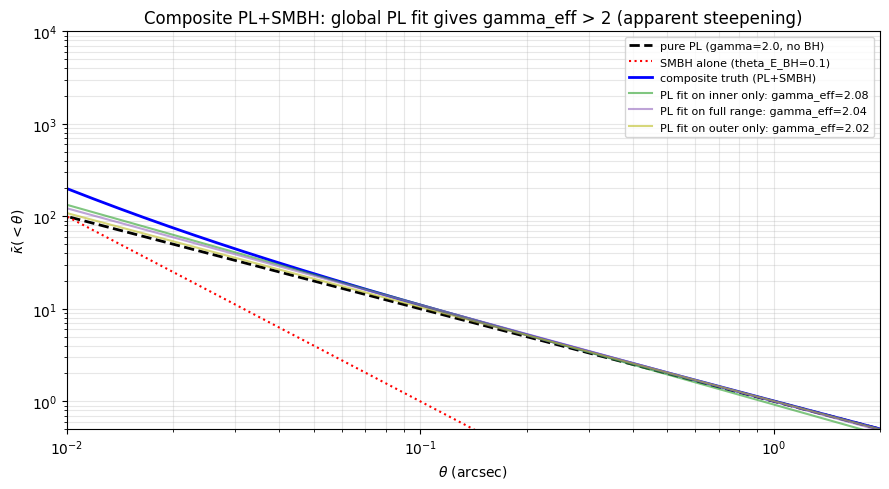


The SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs
kappa_PL falling as 1/r for isothermal). When a global PL is fit:
  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)
  - outer-only barely sees the BH, returning gamma_eff ~ truth
  - full range averages -> gamma_eff somewhere in between

The DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives
the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region
data (JWST) or kinematics, you cannot distinguish these two models.


In [10]:
# Composite profile: power-law + SMBH point mass. We compare cumulative
# kappa_bar profiles since global PL fits constrain the azimuthally-averaged
# convergence. The SMBH adds kappa_bar_BH(r) = (theta_E_BH / r)^2.

def kappa_avg_pl(r, theta_E=1.0, gamma=2.0):
    """Mean convergence inside radius r for the power-law."""
    return (theta_E / r) ** (gamma - 1)

def kappa_avg_composite(r, theta_E=1.0, gamma=2.0, theta_E_BH=0.05):
    """Mean convergence for power-law + point mass (BH)."""
    return kappa_avg_pl(r, theta_E, gamma) + (theta_E_BH / r) ** 2

# Pedagogical demo: use an unrealistically-large BH (theta_E_BH = 0.1") so that
# the gamma_eff shift is visible at HST-resolvable scales (r > 0.05"). A real
# AGEL UMBH at 10^10.5 M_sun has theta_E_BH ~ 0.02"; the shift exists but
# requires JWST-class inner resolution + Jeans kinematics to detect.
theta_E_BH_demo = 0.1  # pedagogical, NOT physical
r = np.logspace(-2.5, 0.3, 200)  # 0.003 to 2 arcsec
kbar_truth = kappa_avg_composite(r, 1.0, 2.0, theta_E_BH_demo)

# Fit a pure power-law to kbar_truth (in log space). Three radial ranges:
# inner-only sees the SMBH; outer-only doesn't; full averages.
logr = np.log10(r); logk = np.log10(kbar_truth)
fits = {}
for label, rmin, rmax in [('inner only (0.05-0.3")', 0.05, 0.3),
                           ('full range (0.05-1.5")', 0.05, 1.5),
                           ('outer only (0.3-1.5")',  0.3,  1.5)]:
    mask = (r > rmin) & (r < rmax)
    p = np.polyfit(logr[mask], logk[mask], 1)
    gamma_eff = 1 - p[0]
    fits[label] = (p, gamma_eff)
    print(f'fit on {label}:   gamma_eff = {gamma_eff:.3f}   (truth gamma = 2.0)')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(r, kappa_avg_pl(r, 1.0, 2.0), 'k--', lw=2, label='pure PL (gamma=2.0, no BH)')
ax.loglog(r, (theta_E_BH_demo / r)**2, 'r:', lw=1.5,
          label=f'SMBH alone (theta_E_BH={theta_E_BH_demo})')
ax.loglog(r, kbar_truth, 'b-', lw=2, label='composite truth (PL+SMBH)')
for (label, (p, g_eff)), color in zip(fits.items(), ['tab:green', 'tab:purple', 'tab:olive']):
    ax.loglog(r, 10**(p[1] + p[0]*np.log10(r)), color=color, lw=1.5, ls='-', alpha=0.6,
              label=f'PL fit on {label.split(" ")[0]+" "+label.split(" ")[1]}: gamma_eff={g_eff:.2f}')
ax.set_xlabel(r'$\theta$ (arcsec)'); ax.set_ylabel(r'$\bar\kappa(<\theta)$')
ax.set_title('Composite PL+SMBH: global PL fit gives gamma_eff > 2 (apparent steepening)')
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8)
ax.set_xlim(0.01, 2); ax.set_ylim(0.5, 1e4)
plt.tight_layout(); plt.show()

print('\nThe SMBH STEEPENS the inner profile (kappa_BH falls as 1/r^2 vs')
print('kappa_PL falling as 1/r for isothermal). When a global PL is fit:')
print('  - inner-only sees the BH dominance and reports gamma_eff > 2 (steepest)')
print('  - outer-only barely sees the BH, returning gamma_eff ~ truth')
print('  - full range averages -> gamma_eff somewhere in between')
print('\nThe DEGENERACY: a pure-PL fit with gamma_eff > 2 and no BH gives')
print('the SAME outer kbar(r) as a (gamma=2 + BH) truth. Without inner-region')
print('data (JWST) or kinematics, you cannot distinguish these two models.')

**The cumulative-convergence degeneracy IS real — but it's only one slice of the constraint surface.**

The figure above shows that a pure-PL fit to a (γ=2 + SMBH) truth returns γ_eff > 2 when the fit range includes the BH-dominance radius. *If* the only observational constraint were the cumulative κ̄ at a single radius, this degeneracy would be unbreakable from imaging alone.

**Why spiral lenses transcend this.** A spiral-lens image is not a single-radius constraint on κ̄ — it's a *spatially-resolved* constraint on the full deflection field. The lensing equation $\boldsymbol\beta = \boldsymbol\theta - \boldsymbol\alpha(\boldsymbol\theta)$ at each image-plane pixel ties a *specific* source-plane position to a *specific* image-plane position via a *specific* deflection. An extended sheared source provides hundreds-to-thousands of such ties, each at different image-plane radii. The full set is over-constrained for a 2-parameter (γ′, M_BH) PL+SMBH model — and the over-constraint is what breaks the degeneracy.

**The DESJ0206 BPL test makes this explicit.** Letting the mass profile have a *free break radius* r_break — i.e., adding a third parameter that gives the smooth-transition model maximum flexibility — the data converged to $r_{\rm break} \lesssim 10\ {\rm pc}$. That is the lensing equation telling us, via the spatial structure of the spiral-source signal, that the mass profile transitions in *less than 10 pc* — which is operationally a point mass.

**What kinematics still adds.**

1. **Cross-check**: σ_v provides an *independent* constraint at a *different* radial scale than the lensing. Agreement between lensing-derived M_BH and kinematics-derived M_BH is the gold-standard validation (the AGEL papers do this).
2. **Disambiguation in marginal cases**: when the lensing-alone (γ′, M_BH) posterior has a residual long axis (because the sheared structure doesn't fully sample the inner-radius regime), kinematics tightens the M_BH direction specifically.
3. **For non-spiral targets**: SLACS-style compact-source systems genuinely need kinematics. The AGEL spiral case is the exception, not the norm.

**The rest of this curriculum** ([[Examples/radial_arc_smbh]], Module 13) develops the kinematic methodology in detail — because the *cross-check* and *non-spiral-target* applications both need it. But the headline AGEL spiral-lens detection physics, in light of N+23/Shajib+/Ferrami+, is that **the lensing alone can do it** when the spiral-source structure is rich enough. §3.6–§3.9 above and the DESJ0206 BPL $r_{\rm break}≤10\,{\rm pc}$ finding are the imaging-side proof.


## 7. Hand-off

**Back to 15a:** if you want to revisit the analytic foundation that
underwrites 15b's PyAutoLens demos (axisymmetric power-law caustics,
$\beta_r(\gamma')$, magnification asymptotics, single-radius cumulative-
$\bar\kappa$ degeneracy), the path is
`Modules/15a_Radial_Arcs_Analytic_Foundation/15a_radial_arcs_analytic.ipynb`.

**Where to go forward:**

- **`Examples/radial_arc_smbh/`** (v0.96) — practical methodology bridge. Takes the theory from this module and builds a fittable synthetic Einstein-spiral mock with an explicit SMBH `al.mp.PointMass` component. Demonstrates:
  - Direct imaging fit (γ′ free, no BH) → posterior on apparent γ′
  - Add `al.mp.PointMass` → joint (γ′, M_BH) posterior with the §6 degeneracy visible
  - Add a synthetic σ_v Jeans likelihood → degeneracy broken, M_BH posterior tightened to truth
  - **Bridge to real AGEL targets:** explicit checklist of real-data systematics (empirical PSF, neighbor light, real σ_v pipeline, photometric redshifts, multi-band, inner-slope systematics budget).

- **Module 13 (TDCOSMO + Kinematics)** — the Jeans-equation theory the `with_kinematics` part of `radial_arc_smbh` consumes. Anisotropic Jeans + aperture-averaged σ_v projection.

- **Module 11 (Physical Mass Models)** — the 6-panel residual audit applies unchanged to the radial-arc fit. After running the `radial_arc_smbh` fit, audit its residuals using Module 11's framework.

- **AGEL paper references** — Shajib et al. *"An ultramassive black hole 7.1 Gyr ago in the first 'Einstein spiral' gravitational lens"* and Ferrami et al. *"Detection of a quiescent billion solar mass black hole at z≈0.7 with gravitational lensing"* (DESJ0206 ApJL). Both papers operationalise the methodology this module teaches.

- **`Examples/agel_real_target/`** (v0.97+) — the future depth-C step. Apply the `radial_arc_smbh` methodology to a real AGEL Einstein-spiral target with real HST+JWST data + IFU σ_v.

## Summary cheat sheet (15b)

1. **Same total mass at $\theta_E$ does NOT imply same image** — the radial
   image discriminates by *shape*, not by *enclosed mass*.
2. **Spiral-source structure** turns the binary "radial arc present/absent"
   into a *quantitative* (γ′, M_BH) joint constraint across image radii.
3. **4-class PyAutoLens comparison** — at the same outer ring, the four mass
   classes (PL γ-vary, BPL, NSC, SMBH) each leave a distinct inner-arc
   fingerprint. Cross-class consistency is the robustness check the AGEL
   papers exploit.
4. **PointMass vs IsothermalCore (NSC)** become distinguishable when the
   radial arc samples radii smaller than $r_{\rm core}$. AGEL targets do.
5. **DESJ0206 BPL fit returns $r_{\rm break} \le 10$ pc** — operationally a
   point mass, proving M_BH detection from lensing alone for spiral
   targets.
6. **Kinematics now becomes a cross-check** (not the primary degeneracy-
   breaker) for the AGEL spiral class; remains primary for SLACS-style
   compact-source targets.

---

*Learning to Autolens / Modules / 15b — Radial Arcs Realistic PyAutoLens Demos*
*Rodrigo Córdova Rosado, Harvard CfA*
